In [197]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer


from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

from sklearn.linear_model import LinearRegression

from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from xgboost import XGBRegressor


In [198]:
df_train = pd.read_csv("data/filtered_train.csv")
df_test = pd.read_csv("data/NaN_clean_test.csv")

In [199]:
print(df_test.shape)
print(df_train.shape)

(1601, 24)
(4709, 25)


In [200]:
#drop ID column 
df_train.drop(columns= ['ID'],inplace=True)
df_train.drop(columns= ['country'],inplace=True)

In [201]:
df_train.shape

(4709, 23)

In [202]:
# Separate numeric features from categorical features in features
numeric_features = df_train.select_dtypes("number").columns
categorical_features = df_train.select_dtypes("object").columns

In [256]:
numeric_features

Index(['total_female', 'total_male', 'total_num_fm', 'night_mainland',
       'night_zanzibar', 'total_nights', 'total_cost'],
      dtype='object')

In [203]:
#Standatization for numerical features

scaler_features =MinMaxScaler()
train_numeric_scaled = scaler_features.fit_transform(df_train[numeric_features])


train_numeric_scaled_df = pd.DataFrame(train_numeric_scaled, columns=numeric_features)
print("Scaled Numeric Features:")
train_numeric_scaled_df.head()

Scaled Numeric Features:


,total_female,total_male,total_num_fm,night_mainland,night_zanzibar,total_nights,total_cost
0,0.02,0.02,0.02,0.14,0.00,0.14,0.01
1,0.02,0.00,0.01,0.16,0.11,0.22,0.05
2,0.00,0.02,0.01,0.01,0.51,0.34,0.06
3,0.02,0.02,0.02,0.12,0.00,0.12,0.13
4,0.02,0.00,0.01,0.08,0.07,0.12,0.03


In [204]:
train_numeric_scaled_df.shape

(4709, 7)

In [205]:
categorical_features

Index(['age_group', 'travel_with', 'purpose', 'main_activity', 'info_source',
       'tour_arrangement', 'package_transport_int', 'package_accomodation',
       'package_food', 'package_transport_tz', 'package_sightseeing',
       'package_guided_tour', 'package_insurance', 'payment_mode',
       'first_trip_tz', 'most_impressing'],
      dtype='object')

In [206]:
#OneHotEncoder foe categorical data
#categorical_features = ['continent', 'age_group', 'travel_with', 'purpose', 'main_activity', 'info_source', 'payment_mode', 'most_impressing']

encoder = OneHotEncoder(sparse=False, handle_unknown='ignore')
train_categorical_encoded = encoder.fit_transform(df_train[categorical_features])

categorical_feature_names = encoder.get_feature_names_out(categorical_features)

train_categorical_encoded_df = pd.DataFrame(train_categorical_encoded, columns=categorical_feature_names)
print("Encoded Categorical Features:")
train_categorical_encoded_df.head()

Encoded Categorical Features:


/Users/nadezdasemenova/MyDisk/NeuFische_Project/Portfolio/2_ML_Project/Project2_ML/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


,age_group_1-24,age_group_25-44,age_group_45-64,age_group_65+,travel_with_Alone,travel_with_Children,travel_with_Friends/Relatives,travel_with_Spouse,travel_with_Spouse and Children,purpose_Business,...,payment_mode_Travellers Cheque,first_trip_tz_No,first_trip_tz_Yes,most_impressing_ Wildlife,most_impressing_Excellent Experience,most_impressing_Friendly People,most_impressing_Good service,most_impressing_No comments,most_impressing_Satisfies and Hope Come Back,"most_impressing_Wonderful Country, Landscape, Nature"
0,0.00,0.00,1.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,...,0.00,1.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00
1,0.00,1.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00
2,0.00,1.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,...,0.00,1.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00
3,0.00,1.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,...,0.00,0.00,1.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00
4,1.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,1.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00


In [207]:
train_transformed_df = pd.concat([train_numeric_scaled_df, train_categorical_encoded_df], axis=1)

train_transformed_df.head()

,total_female,total_male,total_num_fm,night_mainland,night_zanzibar,total_nights,total_cost,age_group_1-24,age_group_25-44,age_group_45-64,...,payment_mode_Travellers Cheque,first_trip_tz_No,first_trip_tz_Yes,most_impressing_ Wildlife,most_impressing_Excellent Experience,most_impressing_Friendly People,most_impressing_Good service,most_impressing_No comments,most_impressing_Satisfies and Hope Come Back,"most_impressing_Wonderful Country, Landscape, Nature"
0,0.02,0.02,0.02,0.14,0.00,0.14,0.01,0.00,0.00,1.00,...,0.00,1.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00
1,0.02,0.00,0.01,0.16,0.11,0.22,0.05,0.00,1.00,0.00,...,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00
2,0.00,0.02,0.01,0.01,0.51,0.34,0.06,0.00,1.00,0.00,...,0.00,1.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00
3,0.02,0.02,0.02,0.12,0.00,0.12,0.13,0.00,1.00,0.00,...,0.00,0.00,1.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00
4,0.02,0.00,0.01,0.08,0.07,0.12,0.03,1.00,0.00,0.00,...,0.00,0.00,1.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00


In [208]:
train_transformed_df.shape

(4709, 69)

In [209]:
features = train_transformed_df.columns.tolist()
features.remove('total_cost')
X = train_transformed_df[features]
y = train_transformed_df['total_cost']

In [210]:
print(X.shape)
print(y.shape)

(4709, 68)
(4709,)


In [211]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Upper bound of target variable before scaling
original_train_max = y_train.max() 
print(original_train_max)

# Retrieve max value stored by MinMaxScaler during fit
original_train_max = scaler_features.data_max_[1]
print(original_train_max)

1.0
44.0


In [213]:
y_train.describe()

count   3767.00
mean       0.13
std        0.17
min        0.00
25%        0.01
50%        0.06
75%        0.16
max        1.00
Name: total_cost, dtype: float64

Basemodel predictions

In [214]:
#as a basemodel
avg_cost = y_train.mean()
predictions = [avg_cost] * len(y_val)  
print(avg_cost)
print(predictions)

0.1275450210882359
[0.1275450210882359, 0.1275450210882359, 0.1275450210882359, 0.1275450210882359, 0.1275450210882359, 0.1275450210882359, 0.1275450210882359, 0.1275450210882359, 0.1275450210882359, 0.1275450210882359, 0.1275450210882359, 0.1275450210882359, 0.1275450210882359, 0.1275450210882359, 0.1275450210882359, 0.1275450210882359, 0.1275450210882359, 0.1275450210882359, 0.1275450210882359, 0.1275450210882359, 0.1275450210882359, 0.1275450210882359, 0.1275450210882359, 0.1275450210882359, 0.1275450210882359, 0.1275450210882359, 0.1275450210882359, 0.1275450210882359, 0.1275450210882359, 0.1275450210882359, 0.1275450210882359, 0.1275450210882359, 0.1275450210882359, 0.1275450210882359, 0.1275450210882359, 0.1275450210882359, 0.1275450210882359, 0.1275450210882359, 0.1275450210882359, 0.1275450210882359, 0.1275450210882359, 0.1275450210882359, 0.1275450210882359, 0.1275450210882359, 0.1275450210882359, 0.1275450210882359, 0.1275450210882359, 0.1275450210882359, 0.1275450210882359, 

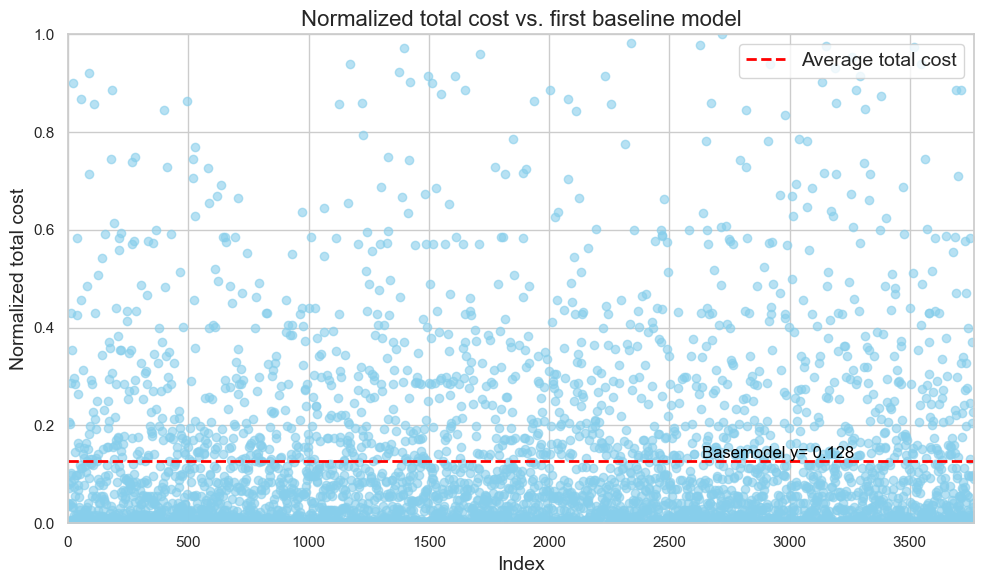

In [215]:
plt.figure(figsize=(10, 6))


plt.scatter(range(len(y_train)), y_train, color='skyblue', alpha=0.6)


avg_cost = y_train.mean()

plt.axhline(y=avg_cost, color='red', linestyle='--', linewidth=2, label='Average total cost')


plt.text(len(y_train) * 0.7, avg_cost, f'Basemodel y= {avg_cost:.3f}', color='black', fontsize=12, verticalalignment='bottom')
plt.ylim(0, 1)
plt.xlim(0, len(y_train))

plt.title('Normalized total cost vs. first baseline model', fontsize=16)
plt.xlabel('Index', fontsize=14)
plt.ylabel('Normalized total cost', fontsize=14)
plt.legend(fontsize=14, loc='upper right')
plt.tight_layout()


plt.show()

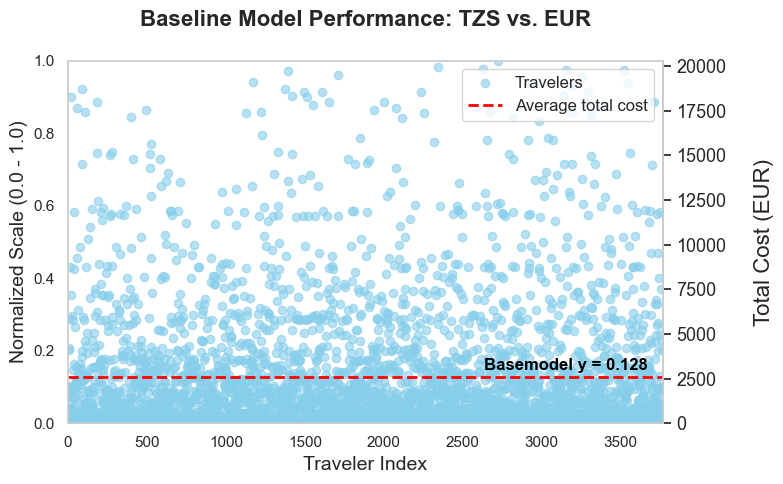

In [216]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# 1. Константы для расчетов
raw_max_cost_tzs = 58012500.0
exchange_rate = 0.00035
# Максимальное значение в Евро для точки 1.0 на графике
max_eur = raw_max_cost_tzs * exchange_rate # ~20304 EUR

# Функции преобразования для secondary_yaxis
# Перевод из нормализованного значения (0-1) в Евро
def norm_to_eur(x):
    return x * max_eur

# Перевод из Евро обратно в нормализованное значение
def eur_to_norm(x):
    return x / max_eur

# 2. Построение основного графика
fig, ax = plt.subplots(figsize=(8, 5))

# Точки (Travelers)
ax.scatter(range(len(y_train)), y_train, color='skyblue', alpha=0.6, label='Travelers')

# Линия среднего (Baseline)
avg_cost = y_train.mean()
ax.axhline(y=avg_cost, color='red', linestyle='--', linewidth=2, label='Average total cost')

# Текст Basemodel
ax.text(len(y_train) * 0.7, avg_cost + 0.02, f'Basemodel y = {avg_cost:.3f}', 
         color='black', fontsize=12, fontweight='bold')

# Настройка основной (левой) оси
ax.set_ylim(0, 1)
ax.set_xlim(0, len(y_train))
ax.set_title('Baseline Model Performance: TZS vs. EUR', fontsize=16, pad=25, fontweight='bold')
ax.set_xlabel('Traveler Index', fontsize=14)
ax.set_ylabel('Normalized Scale (0.0 - 1.0)', fontsize=14)

# --- ТВОЯ ВТОРАЯ ОСЬ (ЕВРО) ---
secax = ax.secondary_yaxis('right', functions=(norm_to_eur, eur_to_norm))
# Подпись оси в Евро
secax.set_ylabel('Total Cost (EUR)', fontsize=16, labelpad=20)

# Форматирование: только целые числа (integer)
secax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%d'))
secax.tick_params(axis='y', labelsize=13)

# --- УДАЛЯЕМ СЕТКУ ---
ax.grid(False)

# Оформление легенды
ax.legend(fontsize=12, loc='upper right', frameon=True)

plt.tight_layout()
plt.show()

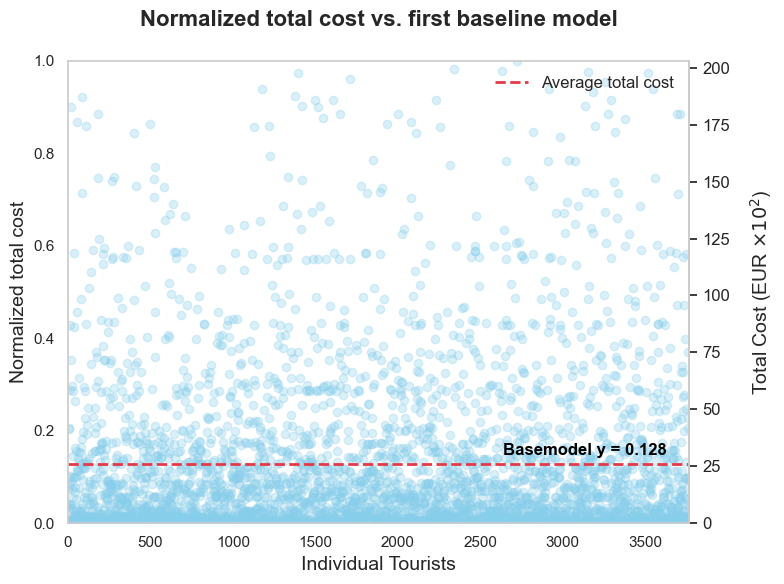

In [217]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# 1. Константы для расчетов
raw_max_cost_tzs = 58012500.0
exchange_rate = 0.00035
max_eur = raw_max_cost_tzs * exchange_rate # ~20304.37 EUR

# Масштабный коэффициент (сотни евро)
scale_factor = 100

# Функции преобразования для secondary_yaxis
# Теперь функция возвращает значение в "сотнях евро"
def norm_to_eur_scaled(x):
    # (0.15 * 20304) / 100 = 30.45 (на оси будет число 30)
    return (x * max_eur) / scale_factor

def eur_scaled_to_norm(x):
    # (30 * 100) / 20304 = 0.147
    return (x * scale_factor) / max_eur

# 2. Построение основного графика
fig, ax = plt.subplots(figsize=(8, 6))

# Точки (Travelers)
ax.scatter(range(len(y_train)), y_train, color='skyblue', alpha=0.3)

# Линия среднего (Baseline)
avg_cost = y_train.mean()
ax.axhline(y=avg_cost, color='#E63946', linestyle='--', linewidth=2, label='Average total cost')

# Текст Basemodel
ax.text(len(y_train) * 0.7, avg_cost + 0.02, f'Basemodel y = {avg_cost:.3f}', 
         color='black', fontsize=12, fontweight='bold')

# Настройка основной (левой) оси
ax.set_ylim(0, 1)
ax.set_xlim(0, len(y_train))
ax.set_title('Normalized total cost vs. first baseline model', fontsize=16, pad=25, fontweight='bold')
ax.set_xlabel('Individual Tourists', fontsize=14)
ax.set_ylabel('Normalized total cost', fontsize=14)

# --- ВТОРАЯ ОСЬ (ЕВРО * 10^2) ---
secax = ax.secondary_yaxis('right', functions=(norm_to_eur_scaled, eur_scaled_to_norm))

# Используем LaTeX для красивого отображения степени
secax.set_ylabel(r'Total Cost (EUR $\times 10^{2}$)', fontsize=14, labelpad=13)

# Форматирование: целые числа (теперь это сотни, например 50, 100, 200)
secax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%d'))
secax.tick_params(axis='y', labelsize=12)

# Убираем сетку
ax.grid(False)

# Оформление легенды
ax.legend(fontsize=12, loc='upper right', frameon=False)

plt.tight_layout()
plt.show()

In [218]:
#as a basemodel
median_cost = y_train.median()
predictions_med = [median_cost] * len(y_val)  
print(median_cost)
print(predictions_med)

0.05768608232746348
[0.05768608232746348, 0.05768608232746348, 0.05768608232746348, 0.05768608232746348, 0.05768608232746348, 0.05768608232746348, 0.05768608232746348, 0.05768608232746348, 0.05768608232746348, 0.05768608232746348, 0.05768608232746348, 0.05768608232746348, 0.05768608232746348, 0.05768608232746348, 0.05768608232746348, 0.05768608232746348, 0.05768608232746348, 0.05768608232746348, 0.05768608232746348, 0.05768608232746348, 0.05768608232746348, 0.05768608232746348, 0.05768608232746348, 0.05768608232746348, 0.05768608232746348, 0.05768608232746348, 0.05768608232746348, 0.05768608232746348, 0.05768608232746348, 0.05768608232746348, 0.05768608232746348, 0.05768608232746348, 0.05768608232746348, 0.05768608232746348, 0.05768608232746348, 0.05768608232746348, 0.05768608232746348, 0.05768608232746348, 0.05768608232746348, 0.05768608232746348, 0.05768608232746348, 0.05768608232746348, 0.05768608232746348, 0.05768608232746348, 0.05768608232746348, 0.05768608232746348, 0.05768608232

In [219]:
rmse = np.sqrt(mean_squared_error(y_val, predictions_med))
print("Baseline RMSE:", rmse)

# Mean Absolute Error (MAE)
mae = mean_absolute_error(y_val, predictions_med)
print("Baseline MAE (Normalized):", mae)

# R-squared (R²)
r2 = r2_score(y_val, predictions_med)
print("Baseline R² (Normalized):", r2)

Baseline RMSE: 0.19960755075800346
Baseline MAE (Normalized): 0.1133126015939861
Baseline R² (Normalized): -0.16196810955603014


In [220]:
rmse = np.sqrt(mean_squared_error(y_val, predictions))
print("Baseline RMSE:", rmse)

# Mean Absolute Error (MAE)
mae = mean_absolute_error(y_val, predictions)
print("Baseline MAE (Normalized):", mae)

# R-squared (R²)
r2 = r2_score(y_val, predictions)
print("Baseline R² (Normalized):", r2)

Baseline RMSE: 0.18523268459814007
Baseline MAE (Normalized): 0.12767770491104868
Baseline R² (Normalized): -0.0006346083706463279


Baseline RMSE (Normalized): 0.185 — Represents the average error of the baseline model in the normalized range, indicating that the predictions deviate on average by 18.5% from the actual values.

Baseline MAE (Normalized): 0.128 — Reflects the average absolute error of the model's predictions, providing a straightforward measure of deviation.

Baseline R² (Normalized): -0.0006 — A negative R² value suggests that the baseline model performs worse than simply predicting the mean, failing to capture data variance effectively.

LinearRegression

In [221]:
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

LinearRegression()

In [222]:
#Prediction
y_pred_lr = linear_model.predict(X_val)

In [223]:
# Intercept and slope/coefficient can be accessed via .intercept_ and .coef_
intercept = linear_model.intercept_
slope = linear_model.coef_[0]
print("Model intercept:", intercept)
print("Coefficient for feature weight:", slope)

Model intercept: 0.1229826431585484
Coefficient for feature weight: 1737218825638.535


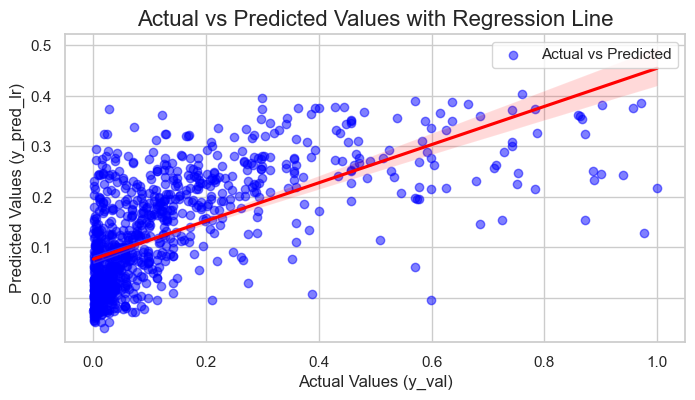

In [224]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


plt.figure(figsize=(8, 4))

plt.scatter(y_val, y_pred_lr, color='blue', alpha=0.5, label='Actual vs Predicted')

# Add a regression line
sns.regplot(x=y_val, y=y_pred_lr, scatter=False, color='red', line_kws={"label": "Regression Line"})

plt.xlabel('Actual Values (y_val)', fontsize=12)
plt.ylabel('Predicted Values (y_pred_lr)', fontsize=12)
plt.title('Actual vs Predicted Values with Regression Line', fontsize=16)
plt.legend()
plt.grid(True)

plt.show()

In [225]:
df = pd.DataFrame(data={"Actual Values": y_val, "Predictions": y_pred_lr})
pd.options.display.float_format = '{:.2f}'.format
df.head(10)


,Actual Values,Predictions
1210,0.02,0.04
1729,0.40,0.38
3321,0.05,0.10
3722,0.00,-0.01
3752,0.07,0.01
291,0.04,0.05
3604,0.02,0.32
2387,0.00,-0.02
3937,0.11,0.09
960,0.03,0.10


In [226]:
#RMSE, MAE и R²
rmse = np.sqrt(mean_squared_error(y_val, y_pred_lr))
mae = mean_absolute_error(y_val, y_pred_lr)
r2 = r2_score(y_val, y_pred_lr)


print("RMSE (Validation Set):", rmse)
print("MAE (Validation Set):", mae)
print("R² (Validation Set):", r2)

RMSE (Validation Set): 0.14285346457992634
MAE (Validation Set): 0.08736119427703334
R² (Validation Set): 0.4048563108981882


In [227]:
y_pred_lr.min()

-0.06021444727289271

Regularization

Ridge

In [228]:
from sklearn.linear_model import Ridge

ridge_model = Ridge(alpha=1.0)  
ridge_model.fit(X_train, y_train)


y_pred_ridge = ridge_model.predict(X_val)


rmse_ridge = np.sqrt(mean_squared_error(y_val, y_pred_ridge))
mae_ridge = mean_absolute_error(y_val, y_pred_ridge)
r2_ridge = r2_score(y_val, y_pred_ridge)

print("RMSE (Ridge):", rmse_ridge)
print("MAE (Ridge):", mae_ridge)
print("R² (Ridge):", r2_ridge)

RMSE (Ridge): 0.14286002082881102
MAE (Ridge): 0.08737254307906606
R² (Ridge): 0.4048016814959777


In [229]:
from sklearn.linear_model import Lasso


lasso_model = Lasso(alpha=0.01)  # 
lasso_model.fit(X_train, y_train)


y_pred_lasso = lasso_model.predict(X_val)


rmse_lasso = np.sqrt(mean_squared_error(y_val, y_pred_lasso))
mae_lasso = mean_absolute_error(y_val, y_pred_lasso)
r2_lasso = r2_score(y_val, y_pred_lasso)

print("RMSE (Lasso):", rmse_lasso)
print("MAE (Lasso):", mae_lasso)
print("R² (Lasso):", r2_lasso)

RMSE (Lasso): 0.1558697592159425
MAE (Lasso): 0.09633908999247406
R² (Lasso): 0.29146059802291435


Ridge regression showed almost identical results to the ordinary linear regression. Perhaps the data does not have a significant overfitting problem and adding regularization does not provide much benefit. In this case, Ridge did not degrade performance, but it did not lead to a meaningful improvement either.

Lasso regression showed lower quality than linear regression and Ridge. This may be due to the fact that Lasso zeros out some coefficients, causing important features to be lost.

Decision Tree

In [230]:
# Decision tree
from sklearn.tree import DecisionTreeRegressor

dt=DecisionTreeRegressor()
dt.fit(X_train, y_train) # Train the model on the training data
 # Evaluate the model on the validation set
y_pred_dt = dt.predict(X_val)

rmse = np.sqrt(mean_squared_error(y_val, y_pred_dt))
mae = mean_absolute_error(y_val, y_pred_dt)
r2 = r2_score(y_val, y_pred_dt)

print("RMSE (Validation Set):", rmse)
print("MAE (Validation Set):", mae)
print("R² (Validation Set):", r2)


RMSE (Validation Set): 0.1909281754230753
MAE (Validation Set): 0.1083150248739273
R² (Validation Set): -0.06311518639886948


In [231]:
df = pd.DataFrame(data={"Actual Values": y_val, "Predictions": y_pred_dt})
pd.options.display.float_format = '{:.2f}'.format
df.head()

,Actual Values,Predictions
1210,0.02,0.02
1729,0.40,0.13
3321,0.05,0.01
3722,0.00,0.01
3752,0.07,0.01


In [232]:
from sklearn.tree import DecisionTreeRegressor      
from sklearn.model_selection import GridSearchCV    
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import pandas as pd

param_grid = {
    'max_depth': [3, 5, 7, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5, 10]
}

dt_regressor = DecisionTreeRegressor(random_state=42)

grid_search = GridSearchCV(
    estimator=dt_regressor,
    param_grid=param_grid,
    scoring='neg_mean_squared_error', 
    cv=5,
    verbose=2,
    n_jobs=-1  
)


grid_search.fit(X_train, y_train)


print("Best Parameters:", grid_search.best_params_)
best_model = grid_search.best_estimator_


y_best_pred_dt = best_model.predict(X_val)


rmse_best = np.sqrt(mean_squared_error(y_val, y_best_pred_dt))
mae_best = mean_absolute_error(y_val, y_best_pred_dt)
r2_best = r2_score(y_val, y_best_pred_dt)

print("Best RMSE (Validation Set):", rmse_best)
print("Best MAE (Validation Set):", mae_best)
print("Best R² (Validation Set):", r2_best)

Fitting 5 folds for each of 48 candidates, totalling 240 fits
[CV] END max_depth=3, min_samples_leaf=1, min_samples_split=2; total time=   0.0s
[CV] END max_depth=3, min_samples_leaf=1, min_samples_split=2; total time=   0.0s
[CV] END max_depth=3, min_samples_leaf=1, min_samples_split=2; total time=   0.0s
[CV] END max_depth=3, min_samples_leaf=1, min_samples_split=2; total time=   0.0s
[CV] END max_depth=3, min_samples_leaf=1, min_samples_split=2; total time=   0.0s
[CV] END max_depth=3, min_samples_leaf=1, min_samples_split=5; total time=   0.0s
[CV] END max_depth=3, min_samples_leaf=1, min_samples_split=5; total time=   0.0s
[CV] END max_depth=3, min_samples_leaf=1, min_samples_split=5; total time=   0.0s
[CV] END max_depth=3, min_samples_leaf=1, min_samples_split=5; total time=   0.0s
[CV] END max_depth=3, min_samples_leaf=1, min_samples_split=5; total time=   0.0s
[CV] END max_depth=3, min_samples_leaf=1, min_samples_split=10; total time=   0.0s
[CV] END max_depth=3, min_samples_l

In [233]:

best_dt_regressor = DecisionTreeRegressor(
    max_depth=5,          
    min_samples_leaf=10,   
    min_samples_split=2,  
    random_state=42        
)


best_dt_regressor.fit(X_train, y_train)


y_val_pred_dt = best_dt_regressor.predict(X_val)


rmse = np.sqrt(mean_squared_error(y_val, y_val_pred_dt))
mae = mean_absolute_error(y_val, y_val_pred_dt)
r2 = r2_score(y_val, y_val_pred_dt)

print("Best RMSE (Validation Set):", rmse)
print("Best MAE (Validation Set):", mae)
print("Best R² (Validation Set):", r2)

Best RMSE (Validation Set): 0.1437515424323014
Best MAE (Validation Set): 0.08422152412848034
Best R² (Validation Set): 0.3973498014251071


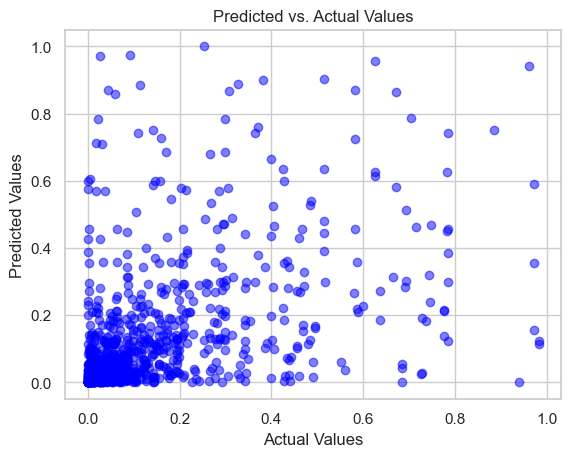

In [234]:
# Scatter plot
plt.scatter(y_pred_dt, y_val, color='blue', alpha=0.5)
plt.title('Predicted vs. Actual Values')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.show()

Random Forest

In [235]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_val)

rmse_rf = np.sqrt(mean_squared_error(y_val, y_pred_rf))
mae_rf = mean_absolute_error(y_val, y_pred_rf)
r2_rf = r2_score(y_val, y_pred_rf)

print("RMSE (Random Forest):", rmse_rf)
print("MAE (Random Forest):", mae_rf)
print("R² (Random Forest):", r2_rf)

RMSE (Random Forest): 0.14586924359790204
MAE (Random Forest): 0.08531198463341602
R² (Random Forest): 0.3794629178197908


In [236]:
n_nodes = []
max_depths = []

for ind_tree in rf_model.estimators_:
    n_nodes.append(ind_tree.tree_.node_count)
    max_depths.append(ind_tree.tree_.max_depth)
    
print(f'Average number of nodes {int(np.mean(n_nodes))}')
print(f'Average maximum depth {int(np.mean(max_depths))}')

Average number of nodes 4535
Average maximum depth 31


In [237]:
feature_importances = pd.DataFrame({'feature': X_train.columns,
                                    'importance': rf_model.feature_importances_})
print(feature_importances.sort_values('importance', ascending=False))


                                         feature  importance
40                 tour_arrangement_Package Tour        0.15
39                  tour_arrangement_Independent        0.10
2                                   total_num_fm        0.08
5                                   total_nights        0.08
3                                 night_mainland        0.06
..                                           ...         ...
66  most_impressing_Satisfies and Hope Come Back        0.00
21                          purpose_Volunteering        0.00
37                info_source_inflight magazines        0.00
58                payment_mode_Travellers Cheque        0.00
57                            payment_mode_Other        0.00

[68 rows x 2 columns]


In [238]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'min_samples_split': [2, 5, 10]
}

rf = RandomForestRegressor(random_state=42)
grid_search = GridSearchCV(rf, param_grid, cv=5, scoring='neg_mean_squared_error')
grid_search.fit(X_train, y_train)

print("The best parameters:", grid_search.best_params_)

The best parameters: {'max_depth': 7, 'min_samples_split': 10, 'n_estimators': 300}


In [239]:

best_params = grid_search.best_params_
optimized_rf = RandomForestRegressor(**best_params, random_state=42)

optimized_rf.fit(X_train, y_train)
y_pred_optimized_rf = optimized_rf.predict(X_val)

rmse_optimized = np.sqrt(mean_squared_error(y_val, y_pred_optimized_rf))
mae_optimized = mean_absolute_error(y_val, y_pred_optimized_rf)
r2_optimized = r2_score(y_val, y_pred_optimized_rf)

print("RMSE (Optimized Random Forest):", rmse_optimized)
print("MAE (Optimized Random Forest):", mae_optimized)
print("R² (Optimized Random Forest):", r2_optimized)

RMSE (Optimized Random Forest): 0.14056459573945507
MAE (Optimized Random Forest): 0.08081322927762441
R² (Optimized Random Forest): 0.42377489830207726


In [240]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
import numpy as np


param_distributions = {
    'n_estimators': [100, 200, 300, 400, 500],  # Number of trees in the forest
    'max_depth': [None, 10, 20, 30, 40],         # Maximum depth of trees
    'min_samples_split': [2, 5, 10],             # Minimum number of samples for splitting a node
    'min_samples_leaf': [1, 2, 4],               # Minimum number of samples on a leaf
    'bootstrap': [True, False]                   # Whether to use the bootstrap method
}


rf = RandomForestRegressor(random_state=42)


random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_distributions,
    n_iter=50,  # Number of hyperparameter combinations to be tested
    cv=5,  # Number of splits for cross-validation
    scoring='neg_mean_squared_error',  # The evaluation metric is negative standardized mean square error
    random_state=42,
    verbose=2,  # Show the parameter setting process
    n_jobs=-1  # Use all CPUs for parallel execution
)


random_search.fit(X_train, y_train)


print("Best Parameters:", random_search.best_params_)

# best result
best_model = random_search.best_estimator_

Fitting 5 folds for each of 50 candidates, totalling 250 fits
[CV] END bootstrap=False, max_depth=40, min_samples_leaf=1, min_samples_split=2, n_estimators=300; total time=   6.4s
[CV] END bootstrap=False, max_depth=40, min_samples_leaf=1, min_samples_split=2, n_estimators=300; total time=   6.5s
[CV] END bootstrap=False, max_depth=40, min_samples_leaf=1, min_samples_split=2, n_estimators=300; total time=   6.5s
[CV] END bootstrap=False, max_depth=40, min_samples_leaf=1, min_samples_split=2, n_estimators=300; total time=   6.6s
[CV] END bootstrap=False, max_depth=40, min_samples_leaf=1, min_samples_split=2, n_estimators=300; total time=   6.9s
[CV] END bootstrap=False, max_depth=40, min_samples_leaf=4, min_samples_split=5, n_estimators=500; total time=   7.6s
[CV] END bootstrap=False, max_depth=40, min_samples_leaf=4, min_samples_split=5, n_estimators=500; total time=   7.6s
[CV] END bootstrap=False, max_depth=40, min_samples_leaf=4, min_samples_split=5, n_estimators=500; total time=  

In [241]:
best_params = {
    'n_estimators': 400,
    'min_samples_split': 2,
    'min_samples_leaf': 4,
    'max_depth': 10,
    'bootstrap': True
}


best_rf_model = RandomForestRegressor(
    n_estimators=best_params['n_estimators'],
    min_samples_split=best_params['min_samples_split'],
    min_samples_leaf=best_params['min_samples_leaf'],
    max_depth=best_params['max_depth'],
    bootstrap=best_params['bootstrap'],
    random_state=42  
)


best_rf_model.fit(X_train, y_train)

y_pred_best_rf = best_rf_model.predict(X_val)


# RMSE
rmse = np.sqrt(mean_squared_error(y_val, y_pred_best_rf))
print("RMSE (Validation Set):", rmse)

# MAE
mae = mean_absolute_error(y_val, y_pred_best_rf)
print("MAE (Validation Set):", mae)

# R² Score
r2 = r2_score(y_val, y_pred_best_rf)
print("R² (Validation Set):", r2)

RMSE (Validation Set): 0.14027496411556556
MAE (Validation Set): 0.08060671482660649
R² (Validation Set): 0.42614706137134084


KNN

In [242]:
from sklearn.neighbors import KNeighborsRegressor

# KNeighbors regressor
knn=KNeighborsRegressor()
knn.fit(X_train, y_train) # Train the model on the training data
 # Evaluate the model on the validation set
y_pred_knn = knn.predict(X_val)

# Evaluating metrics
rmse = np.sqrt(mean_squared_error(y_val, y_pred_knn))
mae = mean_absolute_error(y_val, y_pred_knn)
r2 = r2_score(y_val, y_pred_knn)

print("KNN RMSE (Validation Set):", rmse)
print("KNN MAE (Validation Set):", mae)
print("KNN R² (Validation Set):", r2)

KNN RMSE (Validation Set): 0.14605342054545714
KNN MAE (Validation Set): 0.08394726101478113
KNN R² (Validation Set): 0.3778949275541881


In [243]:
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11],  # Number of nearest neighbors to select
    'weights': ['uniform', 'distance'],  # Neighbor weighting
    'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],  # lgorithms for finding neighbors
    'leaf_size': [20, 30, 40]  # РLeaf size for KD-tree or Ball-tree
}


knn = KNeighborsRegressor()


grid_search = GridSearchCV(
    estimator=knn,
    param_grid=param_grid,
    scoring='neg_mean_squared_error',  # Using MSE to Assess Quality
    cv=5,
    verbose=2,
    n_jobs=-1
)


grid_search.fit(X_train, y_train)


print("Best Parameters:", grid_search.best_params_)
best_knn_model = grid_search.best_estimator_


y_pred_best_knn = best_knn_model.predict(X_val)

# Evaluating metrics
rmse_best = np.sqrt(mean_squared_error(y_val, y_pred_best_knn))
mae_best = mean_absolute_error(y_val, y_pred_best_knn)
r2_best = r2_score(y_val, y_pred_best_knn)

print("Best KNN RMSE (Validation Set):", rmse_best)
print("Best KNN MAE (Validation Set):", mae_best)
print("Best KNN R² (Validation Set):", r2_best)

Fitting 5 folds for each of 120 candidates, totalling 600 fits
[CV] END algorithm=auto, leaf_size=20, n_neighbors=3, weights=uniform; total time=   0.0s
[CV] END algorithm=auto, leaf_size=20, n_neighbors=3, weights=uniform; total time=   0.0s
[CV] END algorithm=auto, leaf_size=20, n_neighbors=3, weights=uniform; total time=   0.0s
[CV] END algorithm=auto, leaf_size=20, n_neighbors=3, weights=uniform; total time=   0.0s
[CV] END algorithm=auto, leaf_size=20, n_neighbors=3, weights=uniform; total time=   0.0s
[CV] END algorithm=auto, leaf_size=20, n_neighbors=3, weights=distance; total time=   0.0s
[CV] END algorithm=auto, leaf_size=20, n_neighbors=3, weights=distance; total time=   0.0s
[CV] END algorithm=auto, leaf_size=20, n_neighbors=3, weights=distance; total time=   0.0s
[CV] END algorithm=auto, leaf_size=20, n_neighbors=5, weights=uniform; total time=   0.0s
[CV] END algorithm=auto, leaf_size=20, n_neighbors=5, weights=uniform; total time=   0.0s
[CV] END algorithm=auto, leaf_size

Gradient Boosting Machines (GBM) and XGBoost

In [244]:
from sklearn.ensemble import GradientBoostingRegressor


gbr = GradientBoostingRegressor(random_state=42)
gbr.fit(X_train, y_train)
y_pred_gbr = gbr.predict(X_val)


rmse_gbr = np.sqrt(mean_squared_error(y_val, y_pred_gbr))
mae_gbr = mean_absolute_error(y_val, y_pred_gbr)
r2_gbr = r2_score(y_val, y_pred_gbr)


print(f"Gradient Boosting RMSE: {rmse_gbr:.3f}")
print(f"Gradient Boosting MAE: {mae_gbr:.3f}")
print(f"Gradient Boosting R²: {r2_gbr:.3f}")

Gradient Boosting RMSE: 0.139
Gradient Boosting MAE: 0.079
Gradient Boosting R²: 0.436


In [245]:
import xgboost as xgb

print("XGBoost version:", xgb.__version__)

XGBoost version: 2.1.2


In [246]:
from xgboost import XGBRegressor

# Baseline XGBoost with manually set hyperparameters
xgb_regressor = XGBRegressor(
    objective='reg:squarederror',   # loss function for regression
    n_estimators=100,             # number of boosting rounds
    learning_rate=0.1,             # step size shrinkage to prevent overfitting
    max_depth=3,                   # maximum tree depth per estimator
    random_state=42                
)


xgb_regressor.fit(X_train, y_train)

y_pred_xgb = xgb_regressor.predict(X_val)

# Evaluating metrics
rmse = np.sqrt(mean_squared_error(y_val, y_pred_xgb))
mae = mean_absolute_error(y_val, y_pred_xgb)
r2 = r2_score(y_val, y_pred_xgb)

print("RMSE (Test Set):", rmse)
print("MAE (Test Set):", mae)
print("R² (Test Set):", r2)

RMSE (Test Set): 0.1392328302718607
MAE (Test Set): 0.07940482434512242
R² (Test Set): 0.4346419502174008


In [247]:
# Hyperparameter tuning via exhaustive grid search
xgb = XGBRegressor(objective='reg:squarederror', random_state=42)


param_grid = {
    'n_estimators': [100, 200, 300, 500],           # number of boosting rounds
    'max_depth': [3, 5, 7, 10],                     # tree complexity control
    'learning_rate': [0.01, 0.05, 0.1],             # shrinkage — lower = more robust, slower
    'subsample': [0.6, 0.8, 1.0],                   # fraction of rows sampled per tree
    'colsample_bytree': [0.6, 0.8, 1.0],            # fraction of features sampled per tree
    'min_child_weight': [1, 5, 10],                 # minimum loss reduction to split a node
    'gamma': [0, 0.1, 0.5]                          # minimum loss reduction to split a node
}


grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring='neg_mean_squared_error',
    cv=3,  
    verbose=2,
    n_jobs=-1  
)


grid_search.fit(X_train, y_train)


print("Best Parameters:", grid_search.best_params_)

# Retrieve best estimator and evaluate on validation set
best_xgb_model = grid_search.best_estimator_
y_pred_best_xgb = best_xgb_model.predict(X_val)


from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

rmse = np.sqrt(mean_squared_error(y_val, y_pred_best_xgb))
mae = mean_absolute_error(y_val, y_pred_best_xgb)
r2 = r2_score(y_val, y_pred_best_xgb)

print(f"RMSE (Best XGBoost): {rmse:.3f}")
print(f"MAE (Best XGBoost): {mae:.3f}")
print(f"R² (Best XGBoost): {r2:.3f}")

Fitting 3 folds for each of 3888 candidates, totalling 11664 fits
[CV] END colsample_bytree=0.6, gamma=0, learning_rate=0.01, max_depth=3, min_child_weight=1, n_estimators=100, subsample=0.6; total time=   0.1s
[CV] END colsample_bytree=0.6, gamma=0, learning_rate=0.01, max_depth=3, min_child_weight=1, n_estimators=100, subsample=0.8; total time=   0.1s
[CV] END colsample_bytree=0.6, gamma=0, learning_rate=0.01, max_depth=3, min_child_weight=1, n_estimators=100, subsample=0.6; total time=   0.1s
[CV] END colsample_bytree=0.6, gamma=0, learning_rate=0.01, max_depth=3, min_child_weight=1, n_estimators=100, subsample=0.8; total time=   0.1s
[CV] END colsample_bytree=0.6, gamma=0, learning_rate=0.01, max_depth=3, min_child_weight=1, n_estimators=100, subsample=0.8; total time=   0.1s
[CV] END colsample_bytree=0.6, gamma=0, learning_rate=0.01, max_depth=3, min_child_weight=1, n_estimators=100, subsample=1.0; total time=   0.1s
[CV] END colsample_bytree=0.6, gamma=0, learning_rate=0.01, max_

In [248]:
import joblib

# Save fitted scaler and encoder
joblib.dump(scaler_features, 'models/scaler_features.pkl')
joblib.dump(encoder, 'models/encoder.pkl')

# Save best model
joblib.dump(best_xgb_model, 'models/best_xgb_model.pkl')

['models/best_xgb_model.pkl']

Error Analysis

In [249]:
residuals = y_val - y_pred_best_xgb

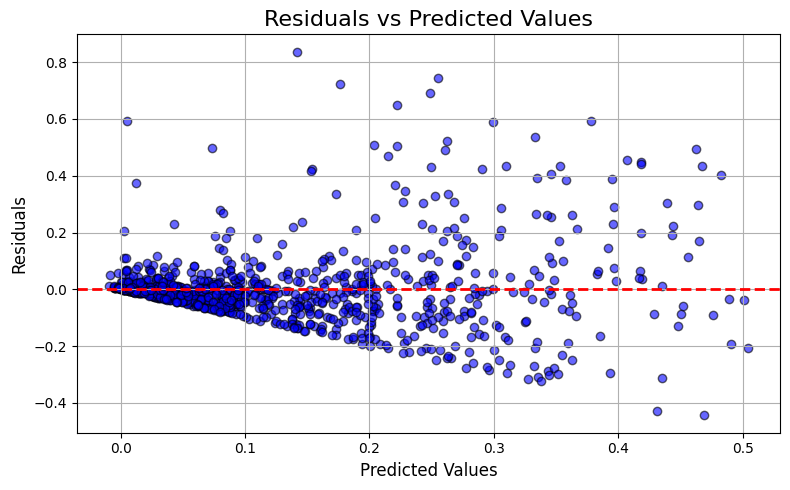

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuals, alpha=0.6, color='blue', edgecolor='k')
plt.axhline(0, color='red', linestyle='--', linewidth=2)
plt.xlabel('Predicted Values', fontsize=12)
plt.ylabel('Residuals', fontsize=12)
plt.title('Residuals vs Predicted Values', fontsize=16)
plt.grid(True)
plt.tight_layout()
plt.show()

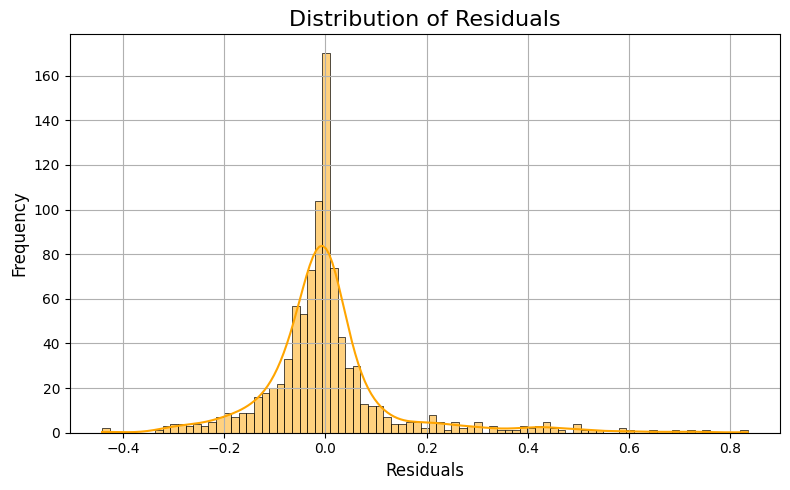

In [ ]:
import seaborn as sns


plt.figure(figsize=(8, 5))
sns.histplot(residuals, kde=True, color='orange')
plt.xlabel('Residuals', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Distribution of Residuals', fontsize=16)
plt.grid(True)
plt.tight_layout()
plt.show()


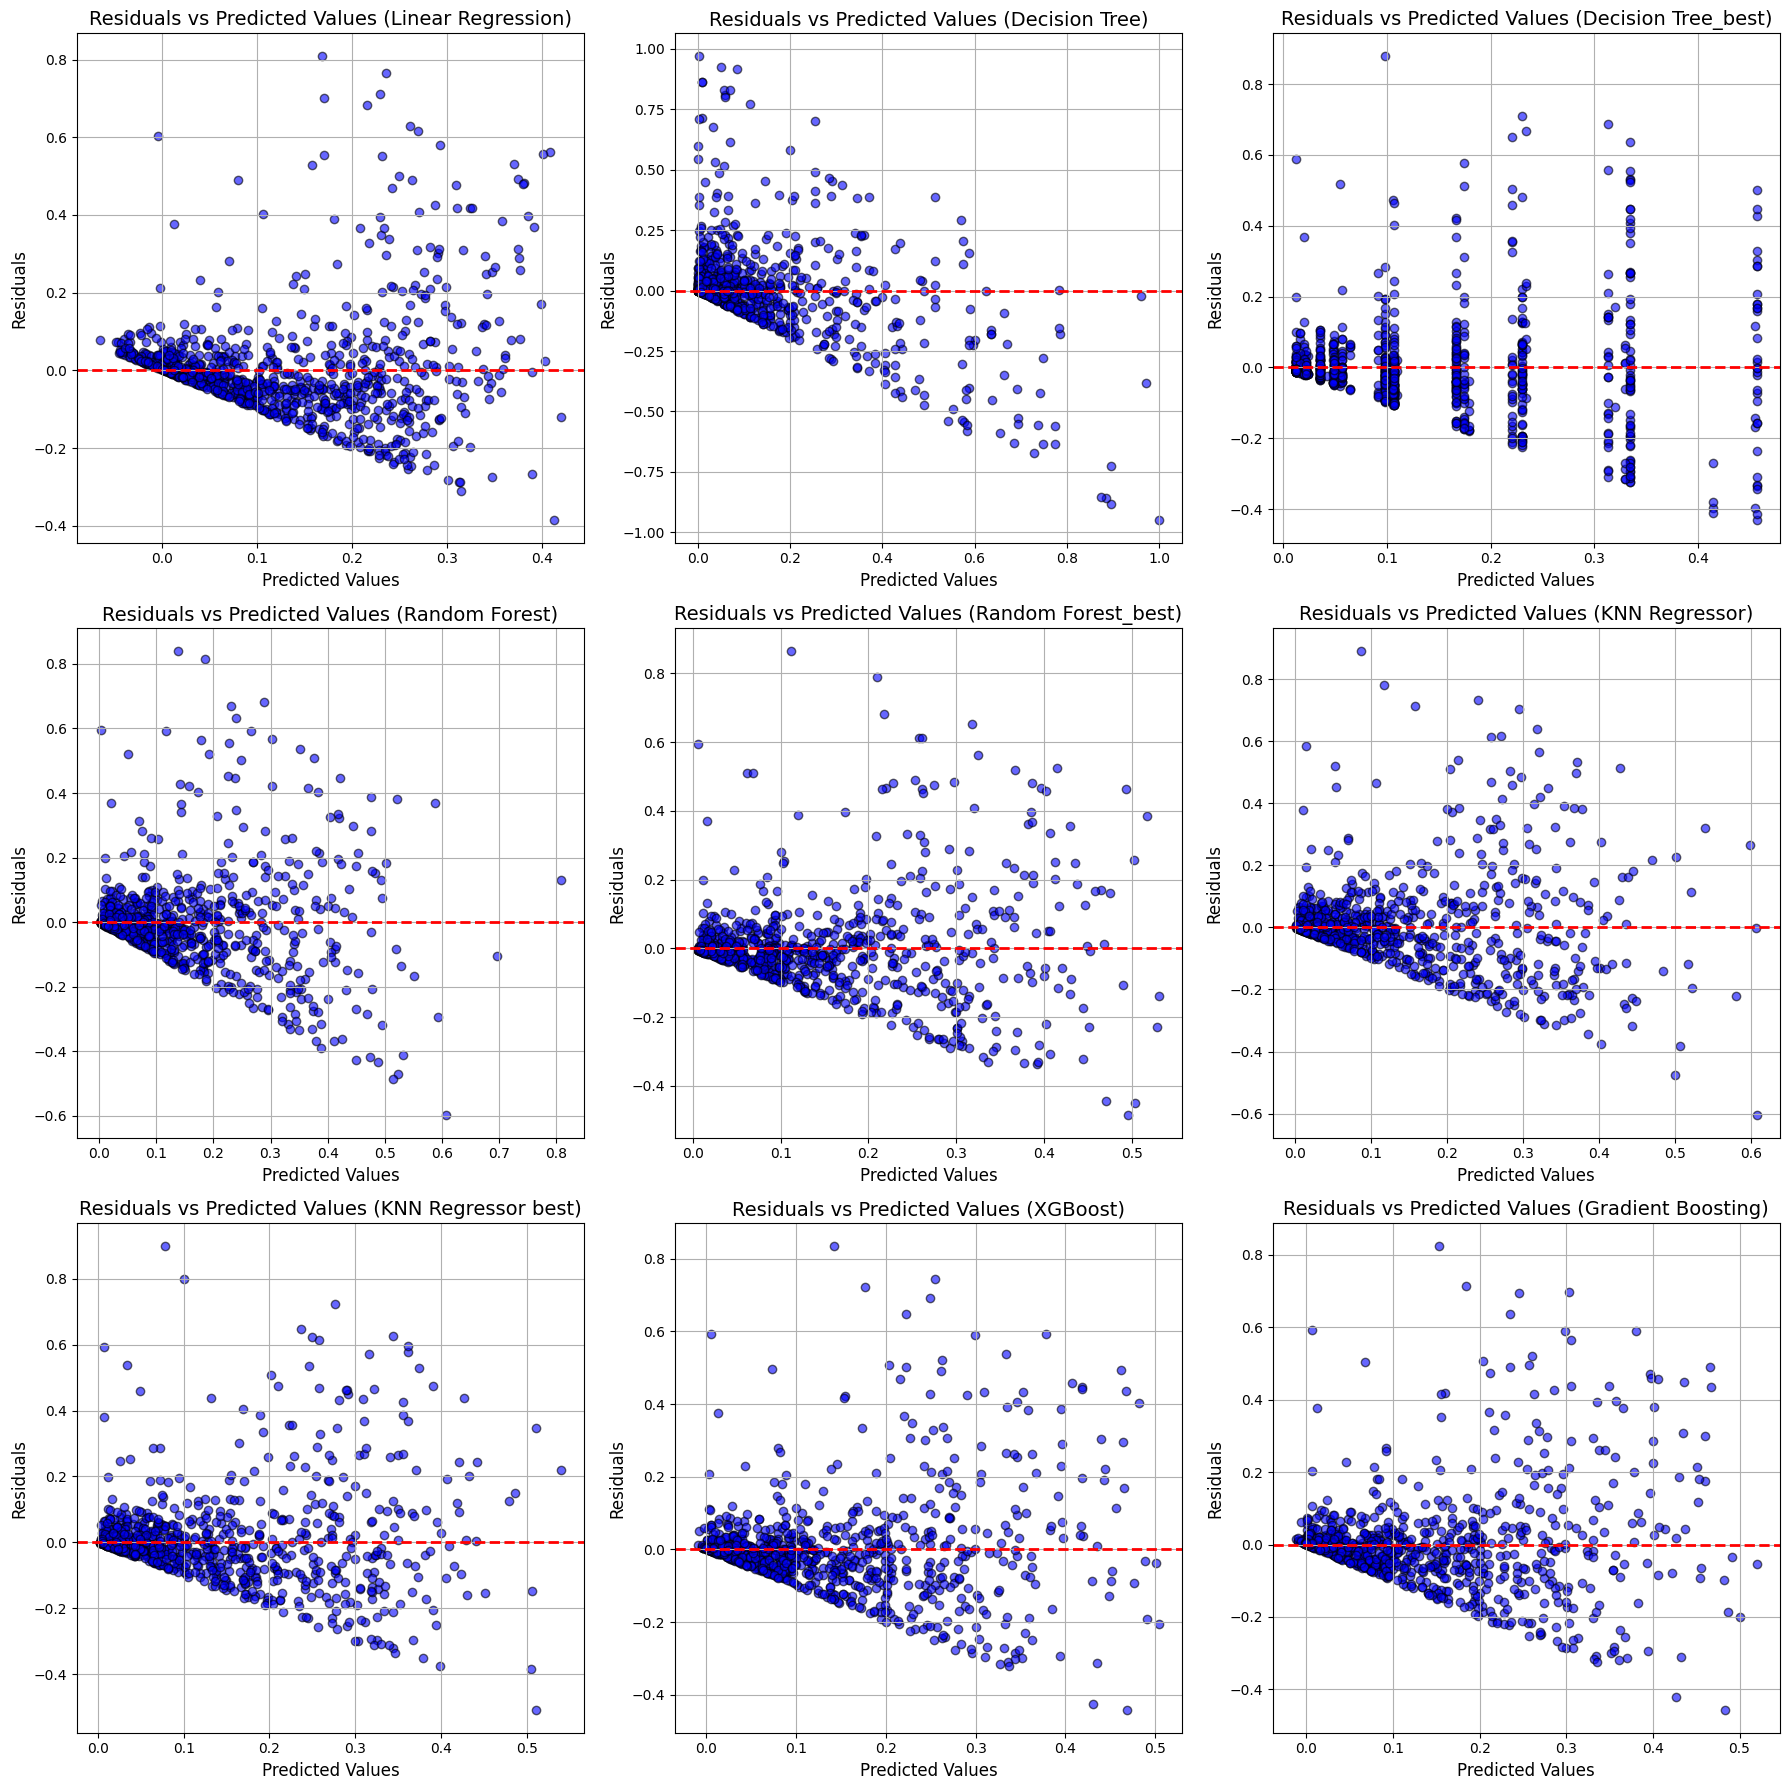

In [ ]:
# y_val_pred_lr - predicted values for Linear Regression
# y_val_pred_ridge - predicted values for Ridge Regression
# y_val_pred_lasso - predicted values for Lasso Regression
# y_val_pred_dt - predicted values for Decision Tree
# y_val_pred_rf - predicted values for Random Forest
# y_val_pred_xgb - predicted values for XGBoost
# y_val_pred_knn - predicted values for KNN Regressor
# y_val_pred_gb - predicted values for Gradient Boosting
# y_val_pred_svr - predicted values for Support Vector Regressor

models_predictions = {
    'Linear Regression': y_pred_lr,
    #'Ridge Regression': y_pred_ridge,
    #'Lasso Regression': y_pred_lasso,
    'Decision Tree': y_pred_dt,
    'Decision Tree_best': y_best_pred_dt,
    'Random Forest': y_pred_rf,
    'Random Forest_best': y_pred_best_rf,
    'KNN Regressor': y_pred_knn,
    'KNN Regressor best': y_pred_best_knn,
    'XGBoost': y_pred_xgb,
    'Gradient Boosting': y_pred_gbr,
    #'SVR': y_val_pred_svr
}


fig, axes = plt.subplots(3, 3, figsize=(18, 18))
axes = axes.flatten()

for i, (model_name, y_pred) in enumerate(models_predictions.items()):
    residuals = y_val - y_pred
    axes[i].scatter(y_pred, residuals, alpha=0.6, color='blue', edgecolor='k')
    axes[i].axhline(0, color='red', linestyle='--', linewidth=2)
    axes[i].set_xlabel('Predicted Values', fontsize=12)
    axes[i].set_ylabel('Residuals', fontsize=12)
    axes[i].set_title(f'Residuals vs Predicted Values ({model_name})', fontsize=14)
    axes[i].grid(True)


for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

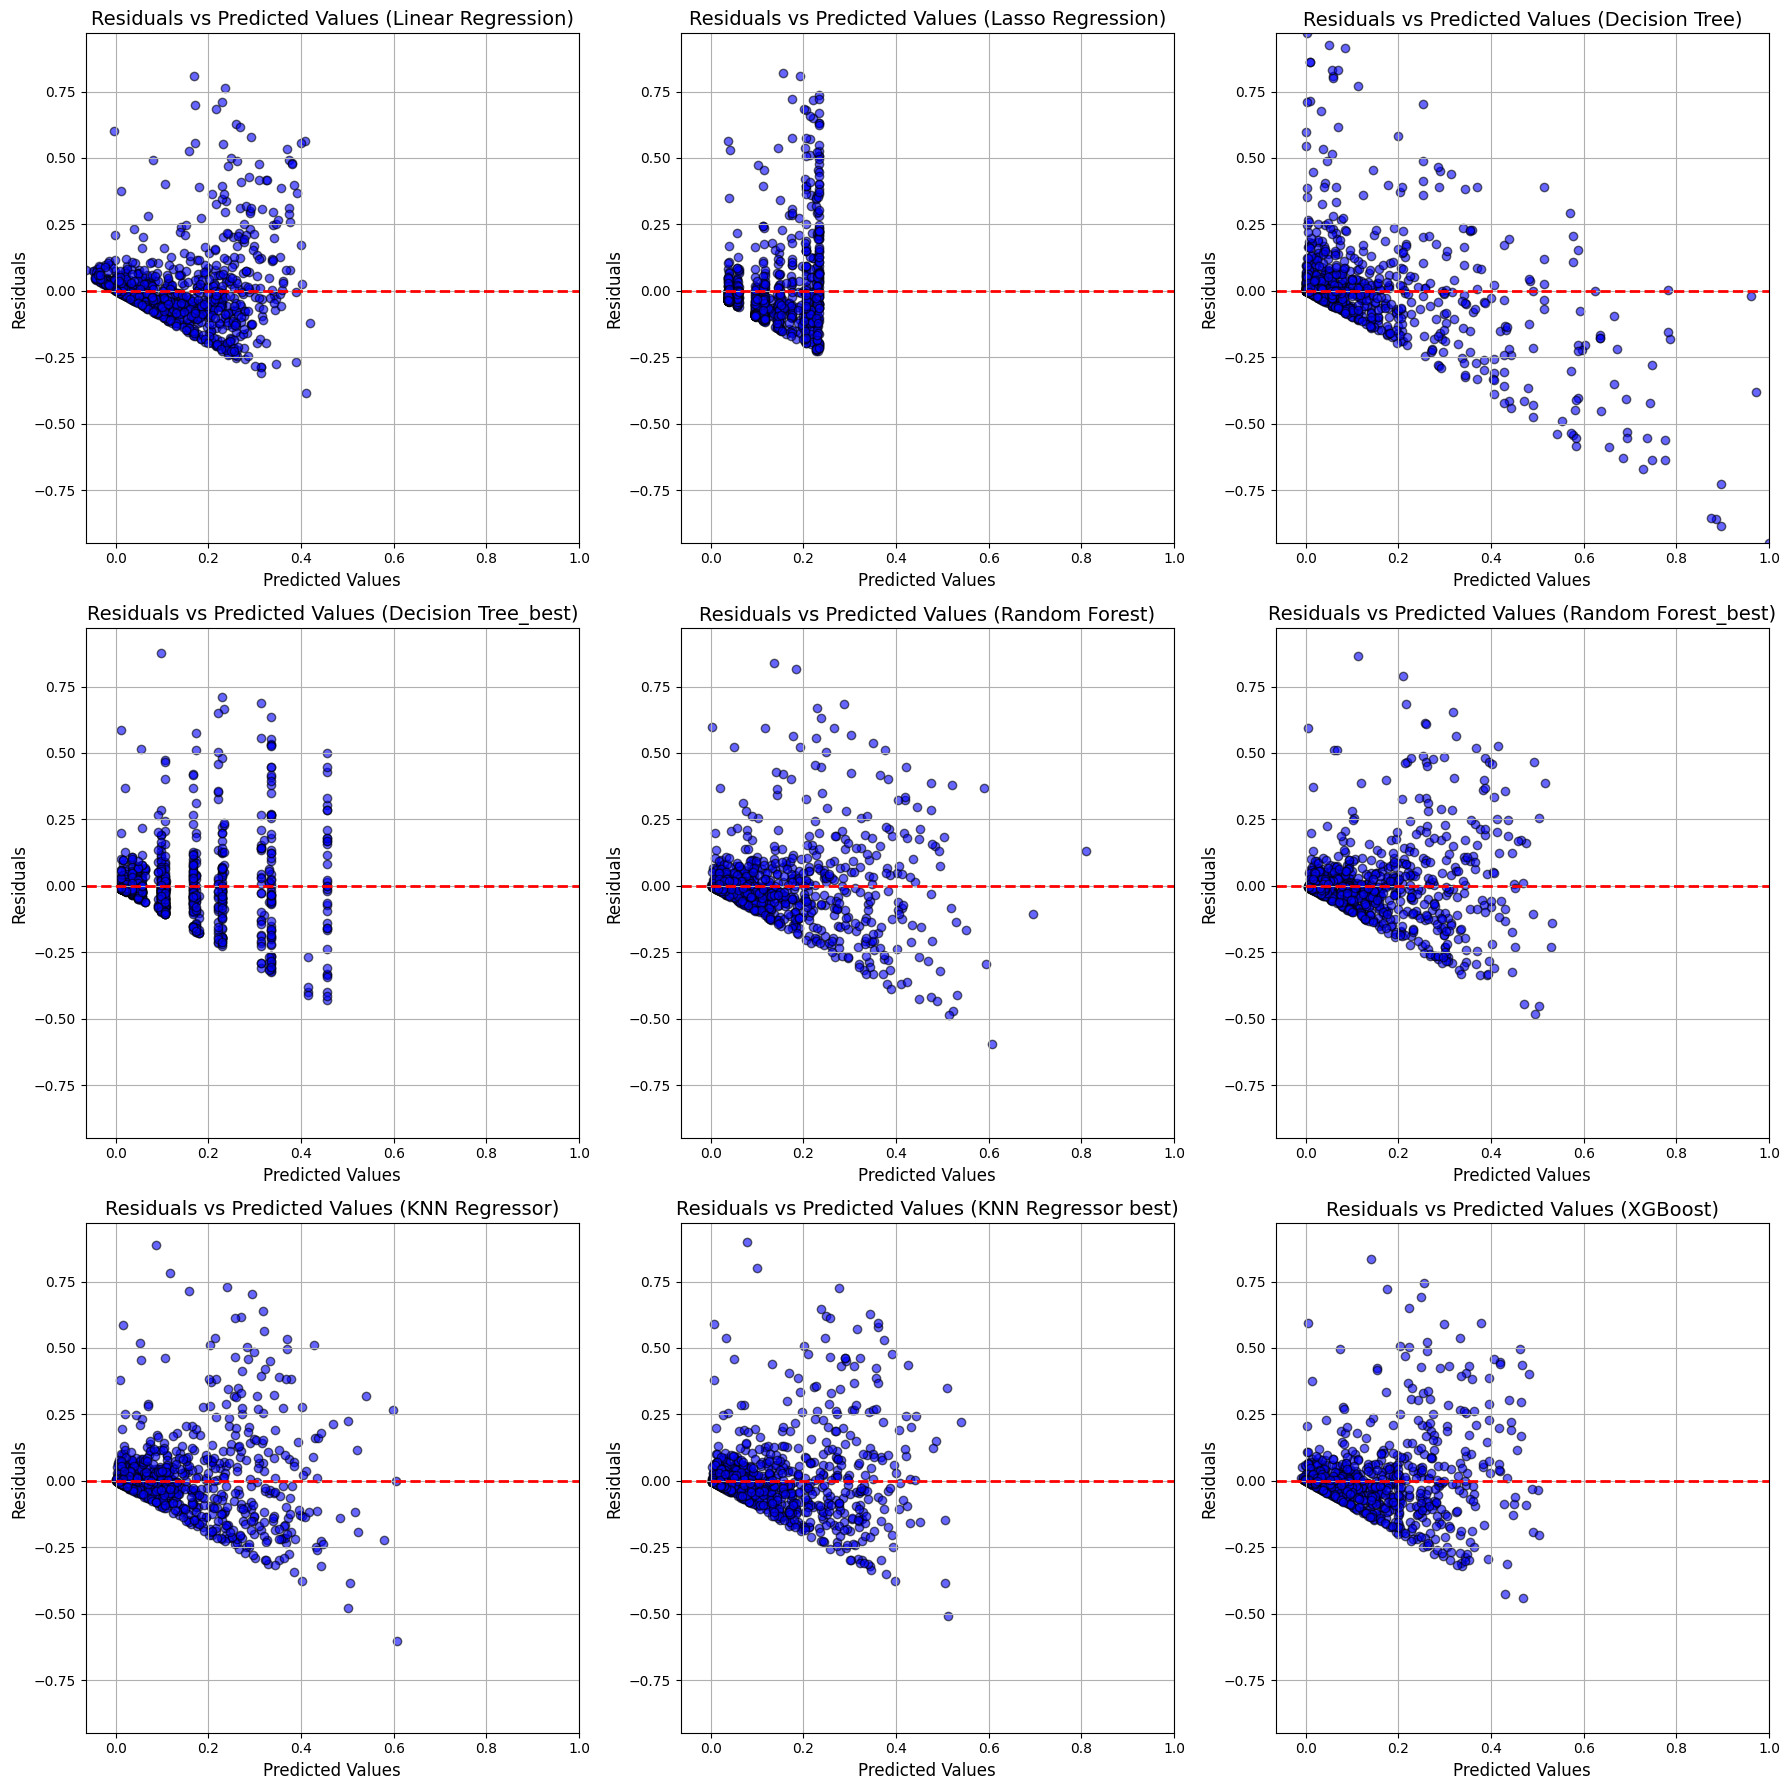

In [ ]:

models_predictions = {
    'Linear Regression': y_pred_lr,
    #'Ridge Regression': y_pred_ridge,
    'Lasso Regression': y_pred_lasso,
    'Decision Tree': y_pred_dt,
    'Decision Tree_best': y_best_pred_dt,
    'Random Forest': y_pred_rf,
    'Random Forest_best': y_pred_best_rf,
    'KNN Regressor': y_pred_knn,
    'KNN Regressor best': y_pred_best_knn,
    'XGBoost': y_pred_xgb,
    #'Gradient Boosting': y_val_pred_gb,
    #'SVR': y_val_pred_svr
}

# Defining a common scale for all charts
# Finding the maximum and minimum values of the residuals and forecasts
all_residuals = [y_val - y_pred for y_pred in models_predictions.values()]
min_residual = min(residual.min() for residual in all_residuals)
max_residual = max(residual.max() for residual in all_residuals)

min_pred = min(y_pred.min() for y_pred in models_predictions.values())
max_pred = max(y_pred.max() for y_pred in models_predictions.values())


fig, axes = plt.subplots(3, 3, figsize=(18, 18))
axes = axes.flatten()

for i, (model_name, y_pred) in enumerate(models_predictions.items()):
    residuals = y_val - y_pred
    axes[i].scatter(y_pred, residuals, alpha=0.6, color='blue', edgecolor='k')
    axes[i].axhline(0, color='red', linestyle='--', linewidth=2)
    axes[i].set_xlabel('Predicted Values', fontsize=12)
    axes[i].set_ylabel('Residuals', fontsize=12)
    axes[i].set_title(f'Residuals vs Predicted Values ({model_name})', fontsize=14)
    axes[i].grid(True)
    axes[i].set_xlim(min_pred, max_pred)  # Установка одинакового лимита по оси X для всех графиков
    axes[i].set_ylim(min_residual, max_residual)  # Установка одинакового лимита по оси Y для всех графиков


for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
models_predictions = {
    'Linear Regression': y_pred_lr,
    'Ridge Regression': y_pred_ridge,
    'Lasso Regression': y_pred_lasso,
    'Decision Tree': y_pred_dt,
    'Decision Tree_best': y_best_pred_dt,
    'Random Forest': y_pred_rf,
    'Random Forest_best': y_pred_best_rf,
    'KNN Regressor': y_pred_knn,
    'KNN Regressor best': y_pred_best_knn,
    'XGBoost': y_pred_xgb,
    'Gradient Boosting': y_pred_gbr
}


results = {}


for model_name, y_pred in models_predictions.items():
    
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    mae = mean_absolute_error(y_val, y_pred)
    r2 = r2_score(y_val, y_pred)

    
    results[model_name] = {
        'RMSE': rmse,
        'MAE': mae,
        'R²': r2
    }

for model_name, metrics in results.items():
    print(f"Model: {model_name}")
    print(f"  RMSE: {metrics['RMSE']:.4f}")
    print(f"  MAE: {metrics['MAE']:.4f}")
    print(f"  R²: {metrics['R²']:.4f}\n")

Model: Linear Regression
  RMSE: 0.1414
  MAE: 0.0873
  R²: 0.4172

Model: Ridge Regression
  RMSE: 0.1412
  MAE: 0.0874
  R²: 0.4182

Model: Lasso Regression
  RMSE: 0.1559
  MAE: 0.0963
  R²: 0.2915

Model: Decision Tree
  RMSE: 0.1920
  MAE: 0.1047
  R²: -0.0751

Model: Decision Tree_best
  RMSE: 0.1426
  MAE: 0.0829
  R²: 0.4067

Model: Random Forest
  RMSE: 0.1419
  MAE: 0.0819
  R²: 0.4130

Model: Random Forest_best
  RMSE: 0.1372
  MAE: 0.0788
  R²: 0.4511

Model: KNN Regressor
  RMSE: 0.1440
  MAE: 0.0838
  R²: 0.3953

Model: KNN Regressor best
  RMSE: 0.1402
  MAE: 0.0806
  R²: 0.4264

Model: XGBoost
  RMSE: 0.1355
  MAE: 0.0783
  R²: 0.4645

Model: Gradient Boosting
  RMSE: 0.1354
  MAE: 0.0784
  R²: 0.4650



In [ ]:
models_predictions = {
    'Basemodel': predictions,
    'Linear Regression': y_pred_lr,
    'Ridge Regression': y_pred_ridge,
    'Lasso Regression': y_pred_lasso,
    'Decision Tree': y_pred_dt,
    'Decision Tree_best': y_best_pred_dt,
    'Random Forest': y_pred_rf,
    'Random Forest_best': y_pred_best_rf,
    'KNN Regressor': y_pred_knn,
    'KNN Regressor best': y_pred_best_knn,
    'XGBoost': y_pred_xgb,
    'Gradient Boosting': y_pred_gbr
}

results = []


for model_name, y_pred in models_predictions.items():
    # Вычисление метрик
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    mae = mean_absolute_error(y_val, y_pred)
    r2 = r2_score(y_val, y_pred)

    results.append([model_name, rmse, mae, r2])

results_df = pd.DataFrame(results, columns=['Model', 'RMSE', 'MAE', 'R²'])

formatted_results_df = results_df.copy()
formatted_results_df[['RMSE', 'MAE', 'R²']] = formatted_results_df[['RMSE', 'MAE', 'R²']].applymap(lambda x: f"{x:.3f}")

formatted_results_df

,Model,RMSE,MAE,R²
0,Basemodel,0.185,0.128,-0.001
1,Linear Regression,0.141,0.087,0.417
2,Ridge Regression,0.141,0.087,0.418
3,Lasso Regression,0.156,0.096,0.291
4,Decision Tree,0.192,0.105,-0.075
5,Decision Tree_best,0.143,0.083,0.407
6,Random Forest,0.142,0.082,0.413
7,Random Forest_best,0.137,0.079,0.451
8,KNN Regressor,0.144,0.084,0.395
9,KNN Regressor best,0.140,0.081,0.426


In [ ]:
formatted_results_df = formatted_results_df.sort_values(by='R²', ascending=True).reset_index(drop=True)

formatted_results_df

,Model,RMSE,MAE,R²
0,Basemodel,0.185,0.128,-0.001
1,Decision Tree,0.192,0.105,-0.075
2,Lasso Regression,0.156,0.096,0.291
3,KNN Regressor,0.144,0.084,0.395
4,Decision Tree_best,0.143,0.083,0.407
5,Random Forest,0.142,0.082,0.413
6,Linear Regression,0.141,0.087,0.417
7,Ridge Regression,0.141,0.087,0.418
8,KNN Regressor best,0.140,0.081,0.426
9,Random Forest_best,0.137,0.079,0.451


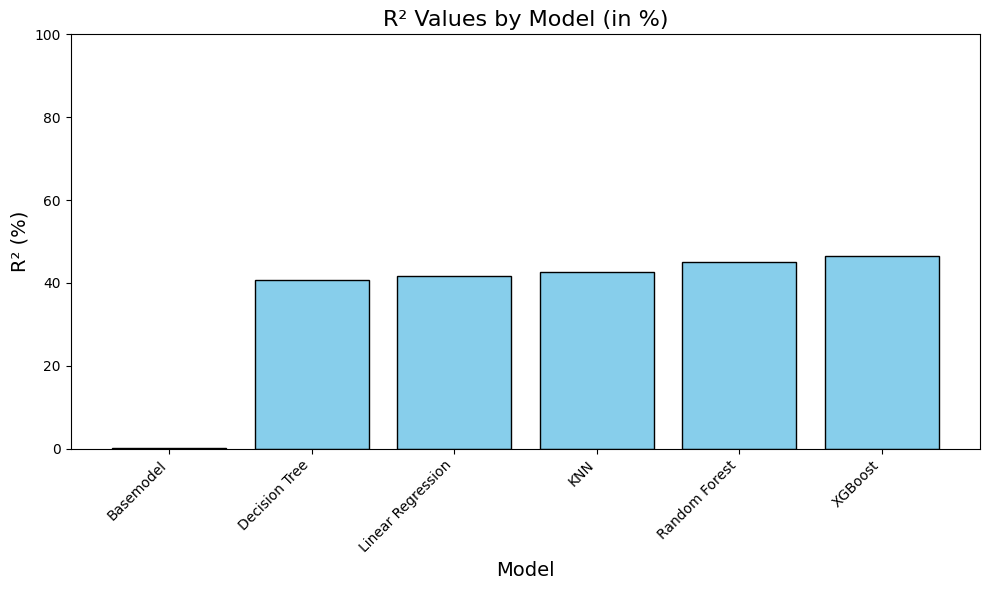

In [ ]:
filtered_df = formatted_results_df[
    ~formatted_results_df['Model'].isin(['Lasso Regression', 'Decision Tree', 'Random Forest', 'Ridge Regression', 'Gradient Boosting','KNN Regressor'])
].copy()


filtered_df['Model'] = filtered_df['Model'].replace({
    'Decision Tree_best': 'Decision Tree',
    'KNN Regressor best': 'KNN',
    'Random Forest_best': 'Random Forest'
})


filtered_df['R²'] = filtered_df['R²'].astype(float)


filtered_df['R²'] = filtered_df['R²'].clip(lower=0)


filtered_df.loc[filtered_df['Model'] == 'Basemodel', 'R²'] = 0.001

# Преобразование значений R² в проценты
filtered_df['R² (%)'] = filtered_df['R²'] * 100


plt.figure(figsize=(10, 6))
plt.bar(filtered_df['Model'], filtered_df['R² (%)'], color='skyblue', edgecolor='black')
plt.title('R² Values by Model (in %)', fontsize=16)
plt.xlabel('Model', fontsize=14)
plt.ylabel('R² (%)', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 100)  
plt.tight_layout()
plt.show()

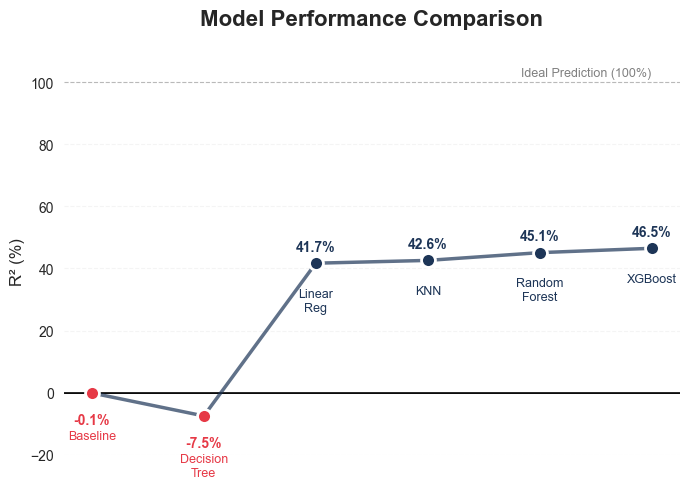

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Данные из таблицы
data = {
    'Model': [
        'Baseline', 'Decision\nTree', 'Linear\nReg', 'KNN', 
        'Random\nForest', 'XGBoost'
    ],
    'R2': [-0.001, -0.075, 0.417, 0.426, 0.451, 0.465]
}
df = pd.DataFrame(data)
df['R2_perc'] = df['R2'] * 100

# Настройка стиля
sns.set_style("white")
plt.figure(figsize=(7, 5))

# Цвета
navy_blue = "#1D3557"
signal_red = "#E63946"

# 1. Линия нуля и линия "Идеала" (100%)
plt.axhline(0, color='black', linewidth=1.2, zorder=1)
plt.axhline(100, color='grey', linestyle='--', linewidth=0.8, alpha=0.5)
plt.text(len(df)-1, 102, 'Ideal Prediction (100%)', color='grey', fontsize=9, ha='right')
# 1. Жирная линия нуля (база)
plt.axhline(0, color='black', linewidth=0.5, zorder=1)

# 2. Основная линия прогресса (чуть прозрачнее, чтобы акцент был на точках)
plt.plot(df['Model'], df['R2_perc'], color=navy_blue, linewidth=2.5, zorder=2, alpha=0.7)

# 3. Маркеры и подписи с условием по цвету
for i, (model, val) in enumerate(zip(df['Model'], df['R2_perc'])):
    # Условие: если меньше 0 — красный, иначе — темно-синий
    current_color = signal_red if val < 0 else navy_blue
    
    # Рисуем точку
    plt.scatter(model, val, color=current_color, s=100, edgecolors='white', linewidths=2, zorder=4)
    
    # Добавляем текст (смещаем вниз для отрицательных, чтобы не накладывался на линию)
    y_pos = val + 4 if val >= 0 else val - 10
    plt.text(i, y_pos, f'{val:.1f}%', 
             ha='center', fontsize=10, fontweight='bold', color=current_color)
    # Название модели (ПОД точкой)
    # Смещаем чуть ниже, чтобы не сливалось с процентами
    y_name = val - 8 if val >= 0 else val - 12
    plt.text(i, y_name, model, 
             ha='center', va='top', fontsize=9, fontweight='500', 
             color=current_color, rotation=0) # Текст теперь строго горизонтальный!

    

# Оформление (шрифты 16 и 12)
plt.title('Model Performance Comparison', fontsize=16, pad=30, fontweight='bold')
plt.ylabel('R² (%)', fontsize=12)

plt.xticks([])

# Шкала: от -25 (чтобы подписи влезли) до 105
plt.ylim(-20, 105)

# Чистим график
sns.despine(left=True, bottom=True)
plt.grid(axis='y', linestyle='--', alpha=0.2)

plt.tight_layout()
plt.show()

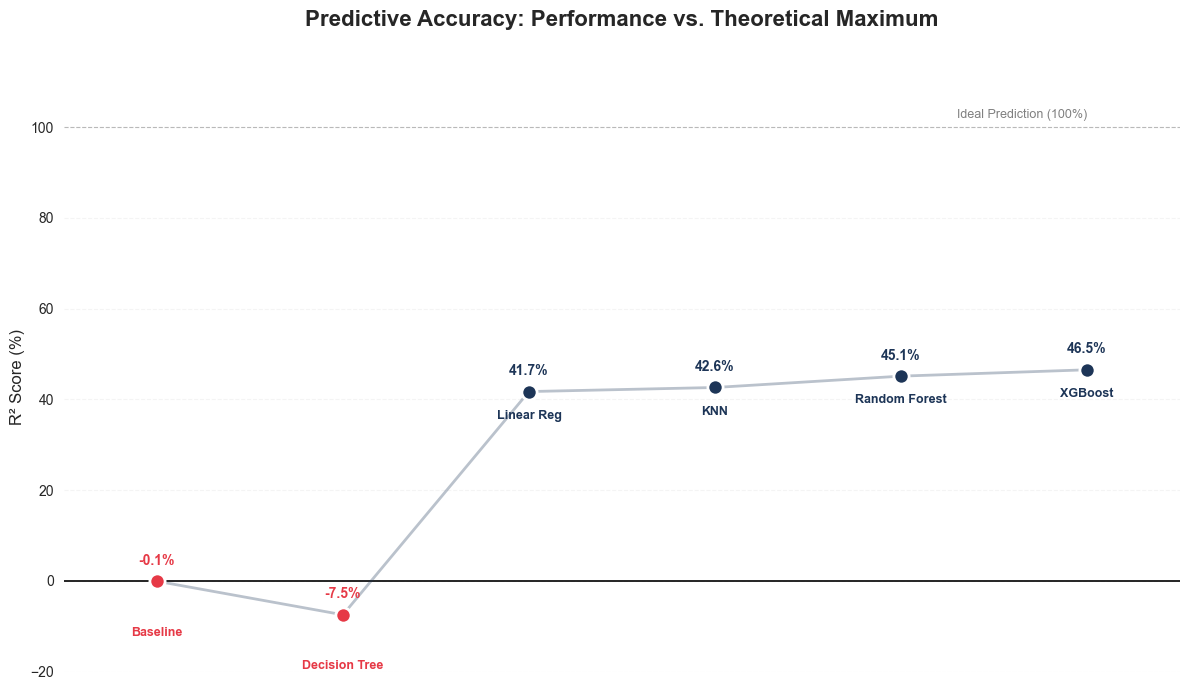

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Данные
data = {
    'Model': [
        'Baseline', 'Decision Tree', 'Linear Reg', 'KNN', 
        'Random Forest', 'XGBoost'
    ],
    'R2': [-0.001, -0.075, 0.417, 0.426, 0.451, 0.465]
}
df = pd.DataFrame(data)
df['R2_perc'] = df['R2'] * 100

# Настройка стиля
sns.set_style("white")
plt.figure(figsize=(12, 7))

navy_blue = "#1D3557"
signal_red = "#E63946"

# 1. Линия нуля и линия "Идеала" (100%)
plt.axhline(0, color='black', linewidth=1.2, zorder=1)
plt.axhline(100, color='grey', linestyle='--', linewidth=0.8, alpha=0.5)
plt.text(len(df)-1, 102, 'Ideal Prediction (100%)', color='grey', fontsize=9, ha='right')

# 2. Линия прогресса
plt.plot(range(len(df)), df['R2_perc'], color=navy_blue, linewidth=2, zorder=2, alpha=0.3)

# 3. Точки и подписи
for i, (model, val) in enumerate(zip(df['Model'], df['R2_perc'])):
    current_color = signal_red if val < 0 else navy_blue
    
    # Маркер
    plt.scatter(i, val, color=current_color, s=120, edgecolors='white', linewidths=2, zorder=4)
    
    # Процент (НАД точкой)
    y_perc = val + 3 if val >= 0 else val + 3
    plt.text(i, y_perc, f'{val:.1f}%', ha='center', va='bottom', 
             fontsize=10, fontweight='bold', color=current_color)
    
    # Название (ПОД точкой)
    y_name = val - 4 if val >= 0 else val - 10
    plt.text(i, y_name, model, ha='center', va='top', 
             fontsize=9, fontweight='bold', color=current_color)

# Оформление
plt.title('Predictive Accuracy: Performance vs. Theoretical Maximum', fontsize=16, pad=40, fontweight='bold')
plt.ylabel('R² Score (%)', fontsize=12)

# Честная шкала до 100%
plt.ylim(-20, 110) 
plt.xlim(-0.5, len(df)-0.5)

# Убираем стандартные подписи и сетку
plt.xticks([]) 
sns.despine(left=True, bottom=True)
plt.grid(axis='y', linestyle='--', alpha=0.2)

plt.tight_layout()
plt.show()

([], [])

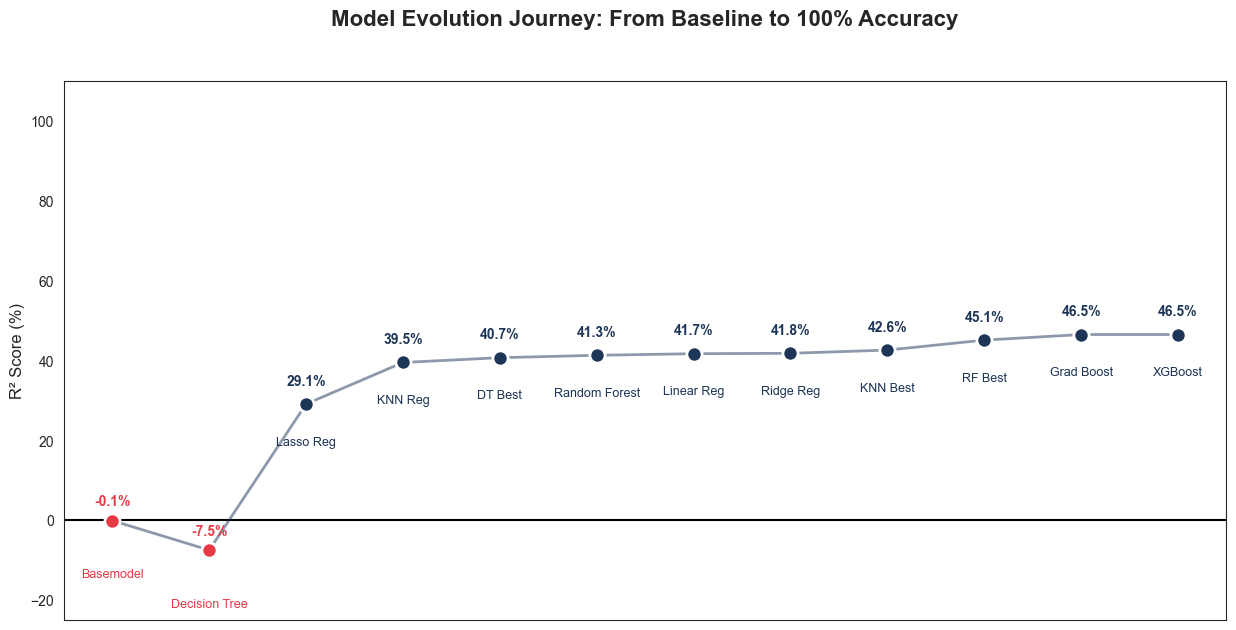

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Данные
data = {
    'Model': [
        'Basemodel', 'Decision Tree', 'Lasso Reg', 'KNN Reg', 'DT Best', 
        'Random Forest', 'Linear Reg', 'Ridge Reg', 'KNN Best', 
        'RF Best', 'Grad Boost', 'XGBoost'
    ],
    'R2': [-0.0011, -0.075, 0.291, 0.395, 0.407, 0.413, 0.417, 0.418, 0.426, 0.451, 0.465, 0.465]
}
df = pd.DataFrame(data)
df['R2_perc'] = df['R2'] * 100

# Настройка стиля
sns.set_style("white")
plt.figure(figsize=(15, 7)) # Чуть шире, чтобы текст не накладывался

# Цвета
navy_blue = "#1D3557"
signal_red = "#E63946"

# 1. Жирная линия нуля
plt.axhline(0, color='black', linewidth=1.5, zorder=1)

# 2. Линия прогресса
plt.plot(range(len(df)), df['R2_perc'], color=navy_blue, linewidth=2, zorder=2, alpha=0.5)

# 3. Нанесение точек, названий и процентов
for i, (model, val) in enumerate(zip(df['Model'], df['R2_perc'])):
    current_color = signal_red if val < 0 else navy_blue
    
    # Рисуем точку
    plt.scatter(i, val, color=current_color, s=120, edgecolors='white', linewidths=2, zorder=4)
    
    # Подпись процента (НАД точкой)
    y_perc = val + 4 if val >= 0 else val + 3
    plt.text(i, y_perc, f'{val:.1f}%', 
             ha='center', va='bottom', fontsize=10, fontweight='bold', color=current_color)
    
    # Название модели (ПОД точкой)
    # Смещаем чуть ниже, чтобы не сливалось с процентами
    y_name = val - 8 if val >= 0 else val - 12
    plt.text(i, y_name, model, 
             ha='center', va='top', fontsize=9, fontweight='500', 
             color=current_color, rotation=0) # Текст теперь строго горизонтальный!

# Оформление
plt.title('Model Evolution Journey: From Baseline to 100% Accuracy', fontsize=16, pad=40, fontweight='bold')
plt.ylabel('R² Score (%)', fontsize=12)

# Шкала: от -25 до 105
plt.ylim(-25, 110)
plt.xlim(-0.5, len(df)-0.5)

# Полностью убираем подписи и деления оси X
plt.xticks([])

In [250]:
#Converter to convert normalized data back to standard data


scaler_target = MinMaxScaler()
scaler_target.fit(df_train[['total_cost']])
joblib.dump(scaler_target,   'models/scaler_target.pkl')

# Extract the minimum and maximum values used for normalization
X_min = scaler_target.data_min_[0]  
X_max = scaler_target.data_max_[0]  



# Normalized Metrics for Optimized Random Forest
rmse_normalized = 0.128
mae_normalized =  0.185
r2_normalized = 0.35655264542496035  # No need to convert R²

# Converting RMSE and MAE from normalized form to their original scale
rmse_original = rmse_normalized * (X_max - X_min)
mae_original = mae_normalized * (X_max - X_min)


print("RMSE (in original scale):", rmse_original)
print("MAE (in original scale):", mae_original)
print("R² (in original scale):", r2_normalized)

RMSE (in original scale): 7417792.0
MAE (in original scale): 10721027.5
R² (in original scale): 0.35655264542496035


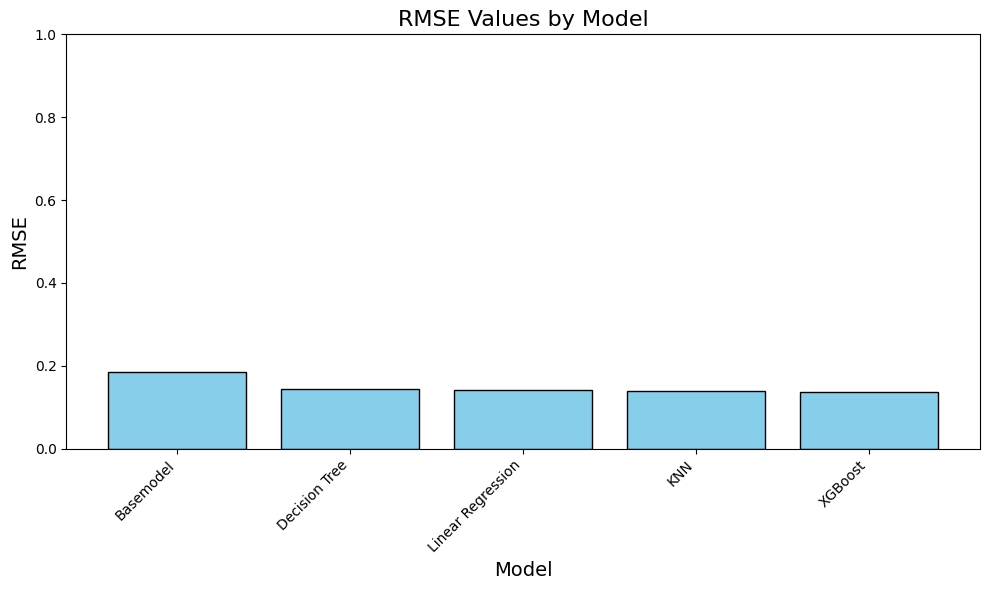

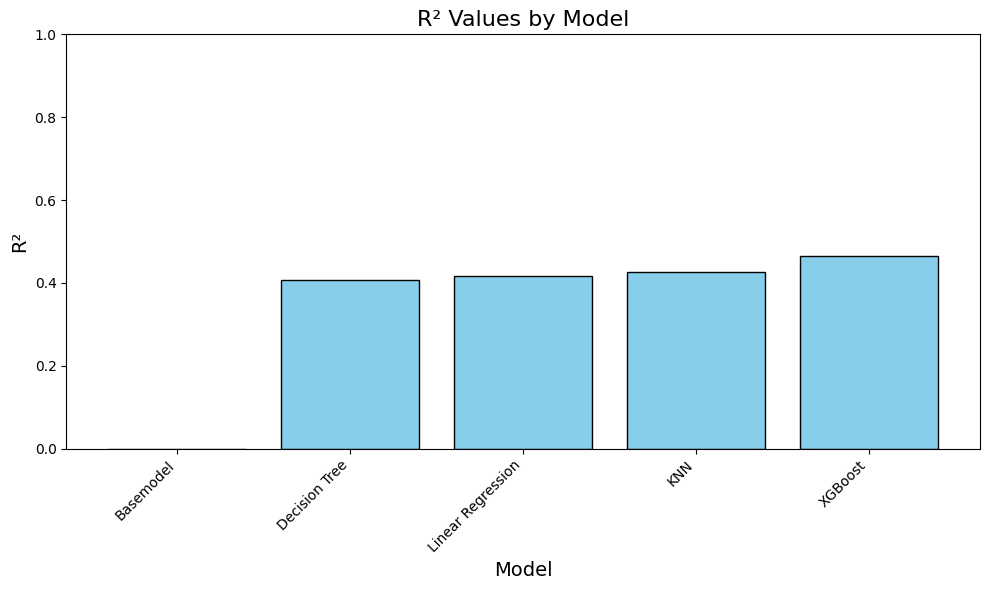

In [120]:
import pandas as pd
import matplotlib.pyplot as plt

# Creating the DataFrame from the given data
data = {
    'Model': [
        'Basemodel', 'KNN Regressor', 'Decision Tree',
        'Linear Regression', 'KNN', 'Random Forest', 'XGBoost'
    ],
    'RMSE': [0.185, 0.144, 0.143, 0.141, 0.140, 0.137, 0.136],
    'MAE': [0.128, 0.084, 0.083,  0.087, 0.081, 0.079, 0.078],
    'R²': [-0.0011, 0.3954, 0.4075, 0.4177, 0.4269, 0.4511, 0.465]
}

df = pd.DataFrame(data)

# Removing 'KNN Regressor' and 'Random Forest' from the DataFrame
df = df[~df['Model'].isin(['KNN Regressor', 'Random Forest'])]

# Plotting a bar chart for RMSE values
plt.figure(figsize=(10, 6))
plt.bar(df['Model'], df['RMSE'], color='skyblue', edgecolor='black')
plt.title('RMSE Values by Model', fontsize=16)
plt.xlabel('Model', fontsize=14)
plt.ylabel('RMSE', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1)  # Setting y-axis limits from 0 to 1
plt.tight_layout()
plt.show()

# Plotting a bar chart for R² values
plt.figure(figsize=(10, 6))
plt.bar(df['Model'], df['R²'], color='skyblue', edgecolor='black')
plt.title('R² Values by Model', fontsize=16)
plt.xlabel('Model', fontsize=14)
plt.ylabel('R²', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1)  # Setting y-axis limits from 0 to 1
plt.tight_layout()
plt.show()


Final model XGBoost


In [260]:
# ── SUBMISSION ────────────────────────────────────────────────────────

# Load cleaned test data; dtype specified to prevent pandas from parsing
# '1-24' age group as a date (known issue with this dataset)
df_test = pd.read_csv('data/NaN_clean_test.csv', dtype={'age_group': str})
df_test['age_group'] = df_test['age_group'].replace('24-Jan', '1-24')

# Preserve IDs for the final submission file, then drop non-feature columns
test_ids = df_test['ID']
df_test.drop(columns=['ID', 'country'], inplace=True)

# Scale numeric features using the scaler fitted on train data
# Note: scaler_features was fitted on numeric_features which includes total_cost,
# so we add a dummy column (0) to match the expected input shape,
# then drop it after transformation
numeric_features_test = [c for c in numeric_features if c != 'total_cost']
df_test_num = df_test[numeric_features_test].copy()
df_test_num['total_cost'] = 0

# Reorder columns to match the order seen during fit
df_test_num = df_test_num[numeric_features]
test_numeric_scaled = scaler_features.transform(df_test_num)
test_numeric_df = pd.DataFrame(test_numeric_scaled, columns=numeric_features)
test_numeric_df.drop(columns=['total_cost'], inplace=True)

# Encode categorical features using the encoder fitted on train data
# handle_unknown='ignore' ensures unseen categories produce a zero vector
categorical_features_test = df_test.select_dtypes('object').columns
test_categorical_encoded = encoder.transform(df_test[categorical_features_test])
test_categorical_df = pd.DataFrame(
    test_categorical_encoded,
    columns=encoder.get_feature_names_out(categorical_features_test)
)

# Combine scaled numeric and encoded categorical features
test_transformed = pd.concat([test_numeric_df, test_categorical_df], axis=1)

# Generate predictions (output is in normalized scale [0, 1])
y_pred_normalized = best_xgb_model.predict(test_transformed)

# Inverse transform predictions back to original TZS scale
# Using min/max of total_cost from train (computed in scaler_target)
y_pred_tzs = y_pred_normalized * (X_max - X_min) + X_min

# Save submission file
submission = pd.DataFrame({'ID': test_ids, 'total_cost': y_pred_tzs})
submission.to_csv('data/submission.csv', index=False)

print(submission.head(10))
print(f"\nShape: {submission.shape}")
print(f"Min:  {y_pred_tzs.min():,.0f} TZS")
print(f"Max:  {y_pred_tzs.max():,.0f} TZS")
print(f"Mean: {y_pred_tzs.mean():,.0f} TZS")

          ID  total_cost
0     tour_1 17474206.00
1   tour_100 11347558.00
2  tour_1001  8732606.00
3  tour_1006  2815932.00
4  tour_1009 22750036.00
5  tour_1010  2453011.50
6  tour_1014  5938831.00
7  tour_1015  2450854.50
8  tour_1019  1651666.38
9  tour_1020  6361803.00

Shape: (1601, 2)
Min:  942,260 TZS
Max:  34,677,104 TZS
Mean: 7,582,575 TZS


In [255]:
print(submission.isnull().sum())
print(submission.dtypes)

ID            0
total_cost    0
dtype: int64
ID             object
total_cost    float32
dtype: object


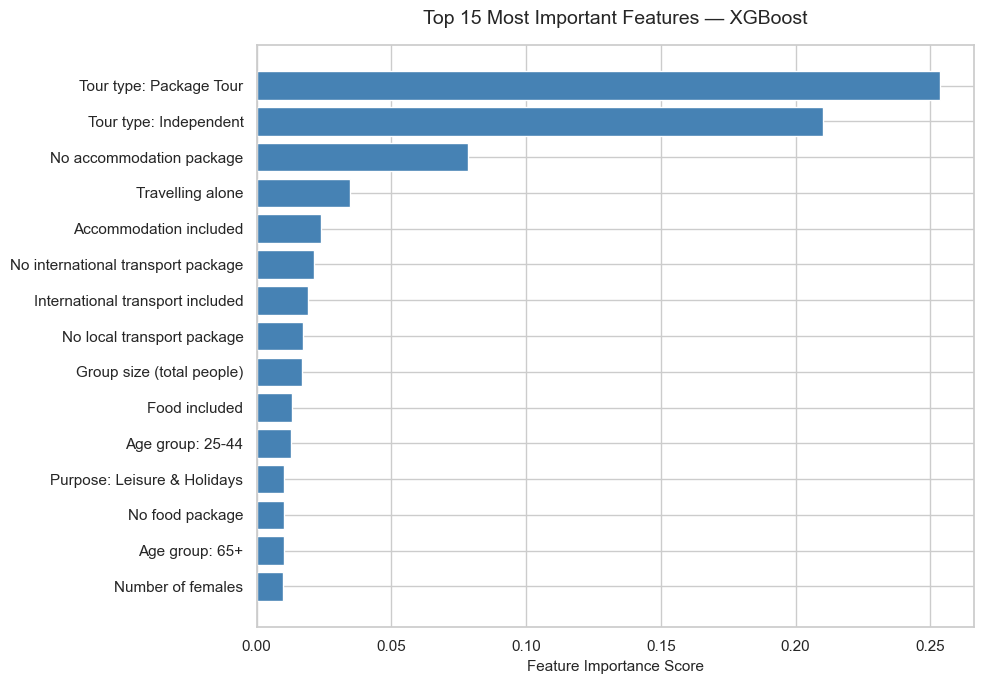

In [ ]:
# Human-readable feature name mapping
feature_labels = {
    'tour_arrangement_Independent':     'Tour type: Independent',
    'tour_arrangement_Package Tour':     'Tour type: Package Tour',
    'total_num_fm':                      'Group size (total people)',
    'total_nights':                        'Total nights',
    'night_mainland':                       'Nights on mainland',
    'night_zanzibar':                      'Nights in Zanzibar',
    'total_female':                        'Number of females',
    'total_male':                          'Number of males',
    'travel_with_Alone':                   'Travelling alone',
    'travel_with_Spouse':                  'Travelling with spouse',
    'travel_with_Children':                'Travelling with children',
    'age_group_25-44':                     'Age group: 25-44',
    'age_group_45-64':                     'Age group: 45-64',
    'age_group_65+':                       'Age group: 65+',
    'age_group_1-24':                      'Age group: 1-24',
    'purpose_Leisure and Holidays':        'Purpose: Leisure & Holidays',
    'purpose_Business':                    'Purpose: Business',
    'main_activity_Wildlife tourism':      'Activity: Wildlife tourism',
    'main_activity_Hunting tourism':       'Activity: Hunting',
    'main_activity_Beach tourism':         'Activity: Beach tourism',
    'package_transport_int_No':            'No international transport package',
    'package_transport_int_Yes':           'International transport included',
    'package_accomodation_No':             'No accommodation package',
    'package_accomodation_Yes':            'Accommodation included',
    'package_transport_tz_No':             'No local transport package',
    'info_source_Travel, agent, tour operator': 'Info source: Travel agent',
    'info_source_Radio, TV, Web':          'Info source: Radio/TV/Web',
    'payment_mode_Cash':                   'Payment: Cash',
    'payment_mode_Credit Card':            'Payment: Credit Card',
    'first_trip_tz_No':                    'Returning visitor',
    'first_trip_tz_Yes':                   'First time visitor',
    'continent_Europe':                    'Continent: Europe',
    'continent_North America':             'Continent: North America',
    'continent_Africa':                    'Continent: Africa',
    'package_food_Yes':                    'Food included',
    'package_food_No':                      'No food package',
}

importances = pd.DataFrame({
    'feature': X_train.columns,
    'importance': best_xgb_model.feature_importances_
}).sort_values('importance', ascending=True).tail(15)

# Apply readable labels — keep original name if not in dictionary
importances['label'] = importances['feature'].map(feature_labels).fillna(importances['feature'])

plt.figure(figsize=(10, 7))
plt.barh(importances['label'], importances['importance'], color='steelblue')
plt.title('Top 15 Most Important Features — XGBoost', fontsize=14, pad=15)
plt.xlabel('Feature Importance Score', fontsize=11)
plt.tight_layout()
plt.show()

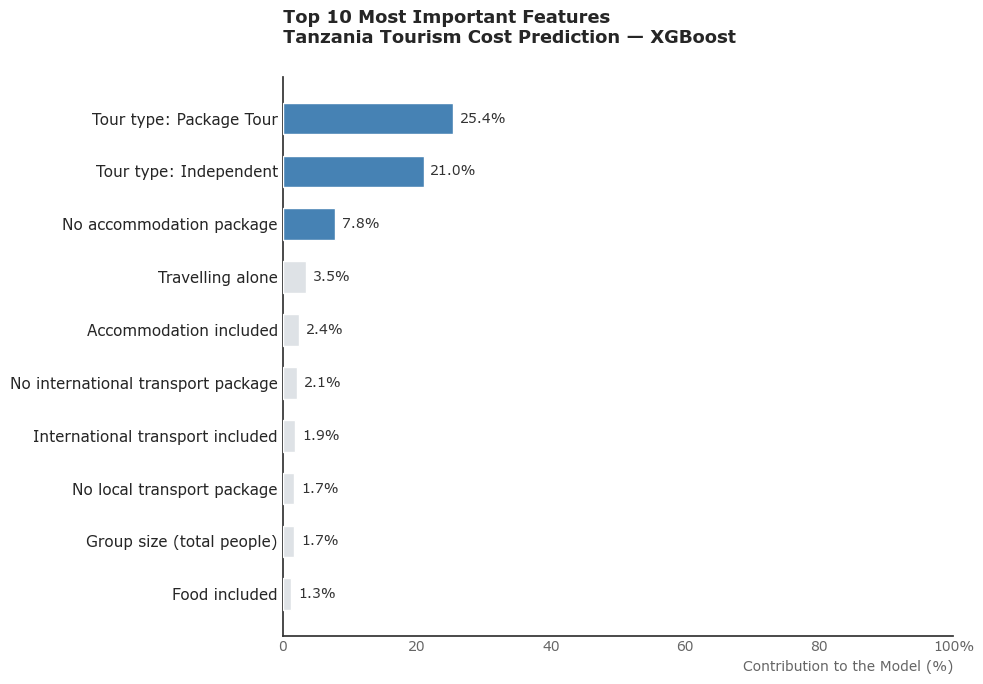

In [ ]:
import matplotlib.pyplot as plt

#  Top-10
df_plot = importances.sort_values('importance', ascending=True).tail(10)
df_plot['importance_pct'] = df_plot['importance'] * 100


colors = ['#dee2e6'] * 7 + ['#4682B4'] * 3 

plt.figure(figsize=(10, 7), facecolor='white')
ax = plt.gca()


ax.grid(False)


bars = ax.barh(df_plot['label'], df_plot['importance_pct'], 
                color=colors, height=0.6, zorder=3)


ax.set_xlim(0, 100)
ax.set_xticks([0, 20, 40, 60, 80, 100])
ax.set_xticklabels(['0', '20', '40', '60', '80', '100%'], fontsize=10, color='#666666')


for bar in bars:
    width = bar.get_width()
    ax.text(width + 1, bar.get_y() + bar.get_height()/2, 
             f'{width:.1f}%', 
             va='center', ha='left', fontsize=10, color='#333333')


ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(True)
ax.spines['left'].set_visible(True)
ax.spines['bottom'].set_color('#333333')
ax.spines['left'].set_color('#333333')


ax.tick_params(axis='both', which='both', length=0)


plt.title('Top 10 Most Important Features\nTanzania Tourism Cost Prediction — XGBoost', 
          fontsize=13, fontweight='bold', pad=25, loc='left')

plt.xlabel('Contribution to the Model (%)', fontsize=10, color='#666666', loc='right')

plt.tight_layout()
plt.show()

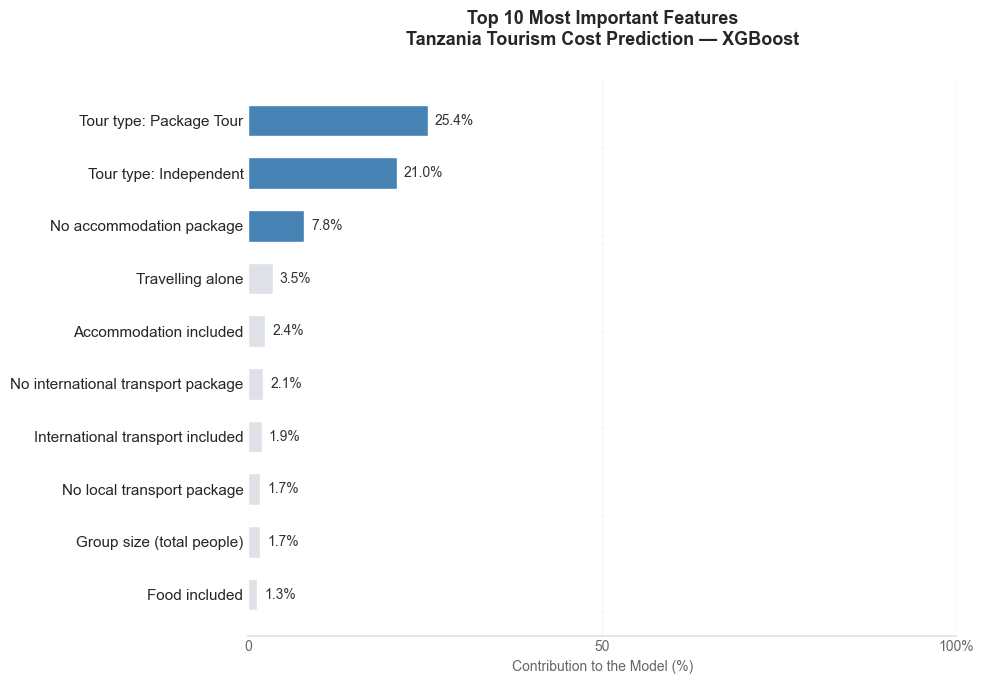

In [ ]:
import matplotlib.pyplot as plt

# 1. Top-10
df_plot = importances.sort_values('importance', ascending=True).tail(10).copy()
df_plot['importance_pct'] = df_plot['importance'] * 100

plt.figure(figsize=(10, 7), facecolor='white')
ax = plt.gca()


ax.grid(False)


colors = ['#dee2e6'] * 7 + ['#4682B4'] * 3 
bars = ax.barh(df_plot['label'], df_plot['importance_pct'], 
                color=colors, height=0.6, zorder=3)


ax.set_xlim(0, 100)
ax.set_xticks([0, 50, 100])
ax.set_xticklabels(['0', '50', '100%'], fontsize=10, color='#666666')


ax.axvline(x=50, color='#f1f3f5', linestyle='--', linewidth=1, zorder=1)
ax.axvline(x=100, color='#e9ecef', linestyle='-', linewidth=1, zorder=1)


for bar in bars:
    width = bar.get_width()
    ax.text(width + 1, bar.get_y() + bar.get_height()/2, 
             f'{width:.1f}%', 
             va='center', ha='left', fontsize=10, color='#333333')


ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)    # Без жирной линии слева
ax.spines['bottom'].set_visible(True)
ax.spines['bottom'].set_color('#dee2e6')


ax.tick_params(axis='both', which='both', length=0)


plt.title('Top 10 Most Important Features\nTanzania Tourism Cost Prediction — XGBoost', 
          fontsize=13, fontweight='bold', pad=25, loc='center')

plt.xlabel('Contribution to the Model (%)', fontsize=10, color='#666666')

plt.tight_layout()
plt.show()

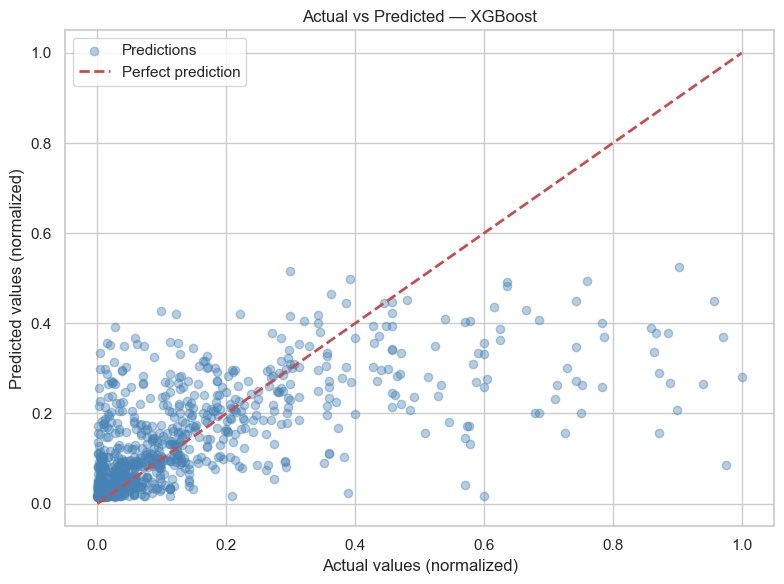

In [265]:
plt.figure(figsize=(8, 6))
plt.scatter(y_val, y_pred_best_xgb, alpha=0.4, color='steelblue', label='Predictions')
plt.plot([y_val.min(), y_val.max()], 
         [y_val.min(), y_val.max()], 
         'r--', linewidth=2, label='Perfect prediction')
plt.xlabel('Actual values (normalized)')
plt.ylabel('Predicted values (normalized)')
plt.title('Actual vs Predicted — XGBoost')
plt.legend()
plt.tight_layout()
plt.show()


Actual vs Predicted scatter plot (validation set, values in EUR) 
Points close to the red diagonal = accurate predictions 
 Key observations: 
- Model performs well in the 0-2500 EUR range (majority of tourists) 
- Predictions deteriorate above 5000 EUR — high-spending tourists are harder to predict 
- Bottom-right outliers: actual ~15 000-20 000 EUR, predicted only 2 000-8 000 EUR 
- This pattern explains R²=0.47: strong on typical tourists, weak on outliers 
 - Potential fix: log-transform the target to compress outliers before training


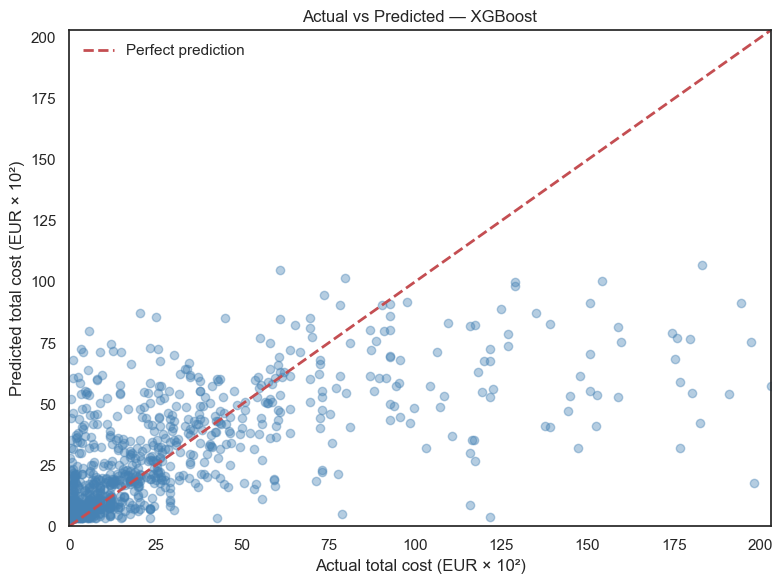

In [ ]:
import matplotlib.pyplot as plt


exchange_rate = 0.00035  # 1 TZS = 0.00035 EUR
scale = 100              #  1 scale = 100 EUR

y_val_eur = ((y_val * (X_max - X_min)) + X_min) * exchange_rate / scale
y_pred_eur = ((y_pred_best_xgb * (X_max - X_min)) + X_min) * exchange_rate / scale

plt.figure(figsize=(8, 6), facecolor='white')


plt.scatter(y_val_eur, y_pred_eur, alpha=0.4, color='steelblue')


max_limit = max(y_val_eur.max(), y_pred_eur.max())
plt.plot([0, max_limit], [0, max_limit], 
         'r--', linewidth=2, label='Perfect prediction')


plt.xlim(0, max_limit)
plt.ylim(0, max_limit)
plt.gca().set_xmargin(0)
plt.gca().set_ymargin(0)


plt.xlabel('Actual total cost (EUR × 10²)')
plt.ylabel('Predicted total cost (EUR × 10²)')
plt.title('Actual vs Predicted — XGBoost')

plt.legend(frameon=False)
plt.tight_layout()
plt.show()

## Key Findings & Conclusions

### Model Performance
The best performing model was **XGBoost** with R²=0.465, RMSE=0.137 (normalized).
This means the model explains approximately 47% of the variance in tourist trip costs.
Performance is moderate — the remaining 53% is likely driven by factors not captured 
in the dataset (individual spending behaviour, trip upgrades, personal preferences).

### Most Important Predictors
Tour arrangement type (Package Tour / Independent) dominates feature importance 
with a combined influence of ~46%, far outweighing demographic factors like age or gender.
This suggests that **how a trip is organised matters more than who the tourist is**.

Top 3 features:
- **Tour type: Package Tour** — 25.4%
- **Tour type: Independent** — 21.0%  
- **No accommodation package** — 7.8%

### Model Limitations
- The model performs well for typical tourists (0–2 500 EUR range)
- Predictions deteriorate significantly for high-spending tourists (above 5 000 EUR)

### Next Steps - 
Try LightGBM and CatBoost as alternative boosting algorithms - Engineer additional features: cost per person, target encoding by country